In [1]:
# ── Installation des dépendances (Google Colab) ──────────────────────────────
# Pandas, numpy, matplotlib, seaborn, requests sont pré-installés sur Colab
# On installe uniquement les libs absentes
!pip install -q missingno openpyxl xlrd
print("✓ Dépendances installées")


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✓ Dépendances installées


# POC Electio-Analytics — Nantes

## Objectif du notebook

Ce notebook présente la construction d’un POC de prévision de tendances électorales pour Electio-Analytics.

L’objectif est de vérifier s’il est possible d’exploiter des données publiques pour analyser et anticiper des tendances électorales à moyen terme. Le projet se concentre sur un périmètre géographique unique : la ville de Nantes, identifiée par le code INSEE `44109`.

La démarche suivie est la suivante :

1. sélectionner une zone géographique exploitable ;
2. collecter des données publiques électorales, sociales, économiques et démographiques ;
3. nettoyer et normaliser les données ;
4. consolider les indicateurs dans un dataset annuel ;
5. construire une variable cible électorale ;
6. analyser les corrélations entre indicateurs et abstention ;
7. entraîner un modèle prédictif supervisé ;
8. produire des projections à 1, 2 et 3 ans.

Le notebook complète le script `pipeline.py`, qui automatise le processus ETL et permet de régénérer les fichiers propres ainsi que la base SQLite.

## Collecte et nettoyage des données

**Périmètre géographique :** Ville de Nantes (code INSEE : `44109`, département `44` – Loire-Atlantique)  
**Objectif :** Constituer un jeu de données nettoyé et normalisé regroupant les indicateurs socio-économiques et électoraux nécessaires à la construction d'un modèle prédictif des tendances électorales.

### Indicateurs collectés
| # | Indicateur | Source |
|---|---|---|
| 1 | Résultats électoraux (présidentielles 2017, 2022) | data.gouv.fr — Ministère de l'Intérieur |
| 2 | Criminalité / Sécurité | data.gouv.fr — SSMSI |
| 3 | Démographie (population) | data.gouv.fr — INSEE |
| 4 | Emploi / Chômage | data.nantesmetropole.fr / INSEE |
| 5 | Activité économique (entreprises) | data.nantesmetropole.fr |
| 6 | Pauvreté / Revenus (Filosofi) | data.gouv.fr — INSEE |
| 7 | Vie associative | data.nantesmetropole.fr |

### Structure du notebook
1. Configuration & imports
2. Collecte et exploration de chaque source
3. Nettoyage individuel par source
4. Consolidation et export final

---
## 0. Configuration & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import gzip
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno

# ── Vérification dépendances XLS ───────────────────────────────────────────
try:
    import xlrd  # noqa: F401
except ImportError:
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, "-m", "pip", "install", "xlrd"])

# ── Paramètres d'affichage ──────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

# ── Constantes Nantes ───────────────────────────────────────────────────────
CODE_COMMUNE  = '44109'          # Code INSEE commune
NOM_COMMUNE   = 'Nantes'
CODE_DEP      = '44'             # Loire-Atlantique
NOM_DEP       = 'Loire-Atlantique'
CODE_REGION   = '52'             # Pays de la Loire

# ── Dossiers de sortie ──────────────────────────────────────────────────────
RAW_DIR   = os.path.join('data', 'raw')
CLEAN_DIR = os.path.join('data', 'clean')
os.makedirs(RAW_DIR,   exist_ok=True)
os.makedirs(CLEAN_DIR, exist_ok=True)

print('✓ Configuration OK')
print(f'  Commune : {NOM_COMMUNE} ({CODE_COMMUNE}) — Dép. {CODE_DEP} — Région {CODE_REGION}')

✓ Configuration OK
  Commune : Nantes (44109) — Dép. 44 — Région 52


In [2]:
# ── Fonctions utilitaires ────────────────────────────────────────────────────

def telecharger_csv(url: str, nom_fichier: str, sep: str = ',', encoding: str = 'utf-8',
                    **kwargs) -> pd.DataFrame | None:
    """Télécharge un CSV et le sauvegarde localement. Retourne un DataFrame."""
    chemin = os.path.join(RAW_DIR, nom_fichier)
    if os.path.exists(chemin):
        print(f'  [cache] {nom_fichier}')
    else:
        print(f'  [↓] Téléchargement : {url}')
        try:
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            with open(chemin, 'wb') as f:
                f.write(r.content)
            print(f'  [✓] Sauvegardé : {nom_fichier}')
        except Exception as e:
            print(f'  [✗] Erreur : {e}')
            return None
    try:
        return pd.read_csv(chemin, sep=sep, encoding=encoding, low_memory=False, **kwargs)
    except Exception as e:
        print(f'  [✗] Lecture échouée : {e}')
        return None


def telecharger_gz_csv(url: str, nom_fichier: str, sep: str = ',',
                       encoding: str = 'utf-8', **kwargs) -> pd.DataFrame | None:
    """Télécharge un fichier CSV.GZ, le décompresse en mémoire et retourne un DataFrame."""
    chemin = os.path.join(RAW_DIR, nom_fichier)
    if os.path.exists(chemin):
        print(f'  [cache] {nom_fichier}')
    else:
        print(f'  [↓] Téléchargement GZ : {url}')
        try:
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            with gzip.open(io.BytesIO(r.content)) as gz:
                contenu = gz.read()
            with open(chemin, 'wb') as f:
                f.write(contenu)
            print(f'  [✓] Décompressé & sauvegardé : {nom_fichier}')
        except Exception as e:
            print(f'  [✗] Erreur : {e}')
            return None
    try:
        return pd.read_csv(chemin, sep=sep, encoding=encoding, low_memory=False, **kwargs)
    except Exception as e:
        print(f'  [✗] Lecture échouée : {e}')
        return None


def rapport_qualite(df: pd.DataFrame, nom: str) -> None:
    """Affiche un rapport de qualité des données d'un DataFrame."""
    print(f'\n{'═'*60}')
    print(f'  RAPPORT QUALITÉ — {nom}')
    print(f'{'═'*60}')
    print(f'  Dimensions  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
    print(f'  Doublons    : {df.duplicated().sum():,}')
    vals_manq = df.isnull().sum()
    taux = (vals_manq / len(df) * 100).round(1)
    if vals_manq.sum() > 0:
        print('  Valeurs manquantes :')
        for col in vals_manq[vals_manq > 0].index:
            print(f'    {col:<35} {vals_manq[col]:>6,}  ({taux[col]:>5.1f}%)')
    else:
        print('  Valeurs manquantes : aucune')
    print(f'{'─'*60}')
    print(df.dtypes.to_string())


def rechercher_dataset_datagouv(query: str, n: int = 3) -> pd.DataFrame:
    """Recherche des datasets sur data.gouv.fr et retourne les résultats."""
    url = f'https://www.data.gouv.fr/api/1/datasets/?q={requests.utils.quote(query)}&page_size={n}'
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        data = r.json()
        resultats = []
        for d in data.get('data', []):
            resources = d.get('resources', [])
            csv_res = next((r for r in resources if r.get('format','').lower() in ('csv','txt')), None)
            resultats.append({
                'id': d.get('id'), 'titre': d.get('title'),
                'organisation': d.get('organization', {}).get('name', ''),
                'url_csv': csv_res.get('url') if csv_res else ''
            })
        return pd.DataFrame(resultats)
    except Exception as e:
        print(f'Erreur API : {e}')
        return pd.DataFrame()


print('✓ Fonctions utilitaires chargées')

✓ Fonctions utilitaires chargées


---
## 1. Données électorales

Source : **Ministère de l'Intérieur** via [data.gouv.fr](https://www.data.gouv.fr/fr/pages/donnees-des-elections/)  
Scrutins collectés : Présidentielles 2017 et 2022 (T1 + T2)

Le code INSEE de Nantes est `44109`. On filtre les fichiers nationaux sur cette valeur.

In [3]:
# ── URLs sources élections ───────────────────────────────────────────────────
# 2022 : Nantes Métropole, résultats par bureau de vote à Nantes
# 2017 : Ministère de l'Intérieur, résultats par canton filtrés ensuite sur Nantes-1 à Nantes-7

URLS_ELECTIONS = {
    "pres_2022_t1": (
        "https://data.nantesmetropole.fr/api/explore/v2.1/catalog/datasets/"
        "244400404_election-presidentielle-2022-nantes-1er-tour/exports/csv"
        "?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B",
        "pres_2022_t1_nantes_complet.csv"
    ),
    "pres_2022_t2": (
        "https://data.nantesmetropole.fr/api/explore/v2.1/catalog/datasets/"
        "244400404_election-presidentielle-2022-nantes-2nd-tour/exports/csv"
        "?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B",
        "pres_2022_t2_nantes_complet.csv"
    ),

    # Présidentielles 2017 — XLS Ministère de l'Intérieur
    "pres_2017_t1": (
        "https://static.data.gouv.fr/resources/election-presidentielle-des-23-avril-et-7-mai-2017-"
        "resultats-du-1er-tour/20170424-095649/Presidentielle_2017_Resultats_Tour_1.xls",
        "pres_2017_t1.xls"
    ),
    "pres_2017_t2": (
        "https://static.data.gouv.fr/resources/election-presidentielle-des-23-avril-et-7-mai-2017-"
        "resultats-definitifs-du-2nd-tour/20170511-092258/"
        "Presidentielle_2017_Resultats_Tour_2_c.xls",
        "pres_2017_t2.xls"
    ),
}

print("URLs élections configurées : 2017 cantons Nantes et 2022 Nantes Métropole")

URLs élections configurées : 2017 cantons Nantes et 2022 Nantes Métropole


## Choix des données électorales

Les données électorales constituent la base de la variable cible du modèle. Elles permettent de calculer le taux d’abstention observé lors des élections passées.

Deux sources sont utilisées :

- les données 2022 proviennent de Nantes Métropole, au niveau des bureaux de vote nantais ;
- les données 2017 proviennent du Ministère de l’Intérieur, au niveau des cantons.

Pour 2022, les données sont directement centrées sur Nantes. Pour 2017, les fichiers disponibles ne proposent pas directement une feuille communale Nantes exploitable. Le choix a donc été fait d’utiliser les cantons `Nantes-1` à `Nantes-7`, qui permettent de rester sur un périmètre proche de la ville de Nantes.

Cette différence de granularité est conservée dans la colonne `niveau_geo_electoral`, afin de garder une traçabilité claire des sources.

In [4]:
# ── Téléchargement des résultats 2022 ────────────────────────────────────────
print('=== Présidentielles 2022 — Tour 1 ===')
url_t1, fichier_t1 = URLS_ELECTIONS['pres_2022_t1']
df_pres22_t1 = telecharger_csv(url_t1, fichier_t1, sep=';', encoding='utf-8')

print('\n=== Présidentielles 2022 — Tour 2 ===')
url_t2, fichier_t2 = URLS_ELECTIONS['pres_2022_t2']
df_pres22_t2 = telecharger_csv(url_t2, fichier_t2, sep=';', encoding='utf-8')

for nom, df in [('T1 2022', df_pres22_t1), ('T2 2022', df_pres22_t2)]:
    if df is not None:
        print(f'\n--- {nom} : {df.shape} ---')
        print(df.columns.tolist())


# ── Téléchargement des résultats 2017 — Cantons Nantes ───────────────────────
def charger_cantons_nantes_2017(url: str, nom_fichier: str, tour_num: int) -> pd.DataFrame | None:
    """
    Charge les résultats 2017 au niveau canton et filtre les cantons Nantes-1 à Nantes-7.

    Objectif :
    - éviter d'utiliser la feuille Région ou Département ;
    - rester sur un périmètre proche de Nantes ;
    - obtenir une donnée électorale exploitable pour le POC Nantes.
    """
    import requests
    import os
    import pandas as pd

    chemin = os.path.join(RAW_DIR, nom_fichier)

    if not os.path.exists(chemin):
        print(f"  Téléchargement {nom_fichier} ...")
        try:
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            with open(chemin, "wb") as f:
                f.write(r.content)
            print(f"  ✓ {nom_fichier} ({len(r.content) // 1024} Ko)")
        except Exception as e:
            print(f"  ✗ Erreur téléchargement : {e}")
            return None
    else:
        print(f"  [cache] {nom_fichier}")

    sheet_name = f"Canton Tour {tour_num}"

    try:
        df_raw = pd.read_excel(chemin, sheet_name=sheet_name, header=None)
    except Exception as e:
        print(f"  ✗ Lecture XLS échouée sur la feuille {sheet_name} : {e}")
        return None

    # Détection de la ligne d'en-tête
    header_row = 0
    for row_idx in range(min(10, len(df_raw))):
        row_vals = df_raw.iloc[row_idx].astype(str)
        if row_vals.str.contains(
            "Code du département|Libellé du canton|Inscrits",
            case=False,
            na=False
        ).any():
            header_row = row_idx
            break

    df = pd.read_excel(chemin, sheet_name=sheet_name, header=header_row)
    df.columns = df.columns.astype(str).str.strip()

    # Normalisation du code département
    df["Code du département"] = (
        df["Code du département"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
        .str.zfill(2)
    )

    # Filtrage sur les cantons nantais
    df_nantes = df[
        (df["Code du département"] == CODE_DEP)
        & (df["Libellé du canton"].astype(str).str.startswith("Nantes-"))
    ].copy()

    df_nantes["annee"] = 2017
    df_nantes["tour"] = f"T{tour_num}"
    df_nantes["scrutin"] = "presidentielle"
    df_nantes["code_commune"] = CODE_COMMUNE
    df_nantes["commune"] = NOM_COMMUNE
    df_nantes["niveau_geo_source"] = "cantons_nantes"
    df_nantes["zone_source"] = "Nantes-1 à Nantes-7"

    print(f'  → Feuille retenue : "{sheet_name}"')
    print(f"  → {len(df_nantes)} canton(s) Nantes retenu(s)")
    print(f"  → Inscrits total : {pd.to_numeric(df_nantes['Inscrits'], errors='coerce').sum():,.0f}")

    return df_nantes


print("\n=== Présidentielles 2017 — Tour 1 ===")
url_17t1, fichier_17t1 = URLS_ELECTIONS["pres_2017_t1"]
df_pres17_t1 = charger_cantons_nantes_2017(url_17t1, fichier_17t1, tour_num=1)

print("\n=== Présidentielles 2017 — Tour 2 ===")
url_17t2, fichier_17t2 = URLS_ELECTIONS["pres_2017_t2"]
df_pres17_t2 = charger_cantons_nantes_2017(url_17t2, fichier_17t2, tour_num=2)

for nom, df in [("T1 2017", df_pres17_t1), ("T2 2017", df_pres17_t2)]:
    if df is not None:
        print(f"\n--- {nom} : {df.shape} ---")
        print(df.columns.tolist()[:15], "...")
        display(df[["Code du département", "Libellé du canton", "Inscrits", "Votants", "annee", "tour"]])

=== Présidentielles 2022 — Tour 1 ===
  [↓] Téléchargement : https://data.nantesmetropole.fr/api/explore/v2.1/catalog/datasets/244400404_election-presidentielle-2022-nantes-1er-tour/exports/csv?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B
  [✓] Sauvegardé : pres_2022_t1_nantes_complet.csv

=== Présidentielles 2022 — Tour 2 ===
  [↓] Téléchargement : https://data.nantesmetropole.fr/api/explore/v2.1/catalog/datasets/244400404_election-presidentielle-2022-nantes-2nd-tour/exports/csv?lang=fr&timezone=Europe%2FParis&use_labels=true&delimiter=%3B
  [✓] Sauvegardé : pres_2022_t2_nantes_complet.csv

--- T1 2022 : (207, 19) ---
['Bureau de vote', 'Nombre d’inscrits', 'Nombre de procurations', 'Nombre de votants', 'Nombre de bulletins blancs', 'Nombre de bulletins nuls', 'Nombre de bulletins exprimés', 'ARTHAUD', 'ROUSSEL', 'MACRON', 'LASSALLE', 'LE PEN', 'ZEMMOUR', 'MELENCHON', 'HIDALGO', 'JADOT', 'PECRESSE', 'POUTOU', 'DUPONT-AIGNAN']

--- T2 2022 : (206, 9) ---
['Bureau de vo

,Code du département,Libellé du canton,Inscrits,Votants,annee,tour
910,44,Nantes-1,27243,22699,2017,T1
911,44,Nantes-2,25759,20861,2017,T1
912,44,Nantes-3,28582,23379,2017,T1
913,44,Nantes-4,25633,21121,2017,T1
914,44,Nantes-5,25384,19365,2017,T1
915,44,Nantes-6,26571,21291,2017,T1
916,44,Nantes-7,28648,23294,2017,T1



--- T2 2017 : (7, 39) ---
['Code du département', 'Libellé du département', 'Code du canton', 'Libellé du canton', 'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins', 'Blancs', '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot'] ...


,Code du département,Libellé du canton,Inscrits,Votants,annee,tour
910,44,Nantes-1,27236,20967,2017,T2
911,44,Nantes-2,25750,19321,2017,T2
912,44,Nantes-3,28579,21492,2017,T2
913,44,Nantes-4,25624,19370,2017,T2
914,44,Nantes-5,25372,18004,2017,T2
915,44,Nantes-6,26570,19825,2017,T2
916,44,Nantes-7,28640,21671,2017,T2


In [5]:
# ── Détection de la colonne code commune / département ───────────────────────

def detecter_col_commune(df: pd.DataFrame) -> str | None:
    """Retourne le nom de la colonne contenant le code commune."""
    candidats = [
        "Code de la commune",
        "code_commune",
        "Code commune",
        "code commune",
        "CodeCommune",
        "insee_com",
        "Code INSEE",
        "code_insee",
        "Libellé de la commune",
        "Commune",
        "commune"
    ]

    for c in candidats:
        if c in df.columns:
            return c

    for c in df.columns:
        c_lower = str(c).lower()
        if "commune" in c_lower and ("code" in c_lower or "libellé" in c_lower):
            return c

    return None


def detecter_col_dep(df: pd.DataFrame) -> str | None:
    """Retourne le nom de la colonne contenant le code département."""
    candidats = [
        "Code du département",
        "code_dep",
        "Code departement",
        "Code département",
        "Département",
        "Departement",
        "dept"
    ]

    for c in candidats:
        if c in df.columns:
            return c

    for c in df.columns:
        c_lower = str(c).lower()
        if ("département" in c_lower or "departement" in c_lower or "partement" in c_lower) and "code" in c_lower:
            return c

    return None


def filtrer_nantes(
    df: pd.DataFrame,
    annee: str,
    tour: str,
    fichier_deja_nantes: bool = False
) -> pd.DataFrame | None:
    """
    Filtre un DataFrame électoral sur Nantes.

    Cas 2017 :
    - Le fichier contient généralement Code du département = 44
    - Et Code de la commune = 109
    - Il faut donc reconstruire le code INSEE 44109

    Cas 2022 :
    - Si le fichier est déjà limité à Nantes, on utilise fichier_deja_nantes=True
    """

    if df is None:
        return None

    df = df.copy()

    # Nettoyer les noms de colonnes
    df.columns = df.columns.astype(str).str.strip()

    col_com = detecter_col_commune(df)
    col_dep = detecter_col_dep(df)

    print(f"  → Colonne commune détectée : {col_com}")
    print(f"  → Colonne département détectée : {col_dep}")

    # Cas 1 : département + commune séparés, exemple fréquent pour 2017
    if col_com and col_dep:
        dep = (
            df[col_dep]
            .astype(str)
            .str.replace(".0", "", regex=False)
            .str.strip()
            .str.zfill(2)
        )

        com = (
            df[col_com]
            .astype(str)
            .str.replace(".0", "", regex=False)
            .str.strip()
            .str.zfill(3)
        )

        code_insee_reconstruit = dep + com
        masque = code_insee_reconstruit == CODE_COMMUNE

        df_nantes = df[masque].copy()

    # Cas 2 : une seule colonne commune existe
    elif col_com:
        code = (
            df[col_com]
            .astype(str)
            .str.replace(".0", "", regex=False)
            .str.strip()
        )

        # Si c'est un code sur 3 chiffres, exemple 109, on ajoute le département 44
        code_normalise = code.apply(
            lambda x: CODE_DEP + x.zfill(3) if x.isdigit() and len(x) <= 3 else x.zfill(5)
        )

        masque = code_normalise == CODE_COMMUNE
        df_nantes = df[masque].copy()
        
    # Cas 3 : seulement une colonne département existe
    # Utilisé pour les fichiers 2017 fournis, qui ne contiennent pas de feuille commune.
    elif col_dep:
        dep = (
            df[col_dep]
            .astype(str)
            .str.replace(".0", "", regex=False)
            .str.strip()
            .str.zfill(2)
        )

        masque = dep == CODE_DEP
        df_nantes = df[masque].copy()

        print(f"  ⚠ Données communales absentes pour {annee} {tour}.")
        print(f"  → Utilisation du département {CODE_DEP} comme proxy électoral.")

    # Cas 4 : fichier déjà limité à Nantes
    elif fichier_deja_nantes:
        print("  ⚠ Aucune colonne commune/département détectée.")
        print("  → On considère que le fichier est déjà limité à Nantes.")
        df_nantes = df.copy()

    else:
        raise ValueError(
            "Impossible de filtrer Nantes : aucune colonne commune/département détectée "
            "et fichier_deja_nantes=False."
        )

    df_nantes["annee"] = int(annee)
    df_nantes["tour"] = tour
    df_nantes["scrutin"] = "presidentielle"
    df_nantes["code_commune"] = CODE_COMMUNE
    df_nantes["commune"] = "Nantes"

    print(f"  → {len(df_nantes)} ligne(s) retenue(s) pour Nantes ({CODE_COMMUNE})")

    return df_nantes


print("✓ Fonctions de filtrage définies")


print('✓ Fonctions de filtrage définies')

✓ Fonctions de filtrage définies
✓ Fonctions de filtrage définies


In [6]:
# ── Filtrage / standardisation sur Nantes ────────────────────────────────────

print("=== Filtrage T1 2022 ===")
nantes_pres22_t1 = filtrer_nantes(df_pres22_t1, "2022", "T1", fichier_deja_nantes=True)

print("\n=== Filtrage T2 2022 ===")
nantes_pres22_t2 = filtrer_nantes(df_pres22_t2, "2022", "T2", fichier_deja_nantes=True)

print("\n=== Filtrage T1 2017 ===")
# Les fichiers 2017 ont déjà été filtrés sur les cantons Nantes-1 à Nantes-7
# dans la fonction charger_cantons_nantes_2017().
nantes_pres17_t1 = df_pres17_t1.copy()
print(f"  → {len(nantes_pres17_t1)} canton(s) Nantes retenu(s) pour 2017 T1")

print("\n=== Filtrage T2 2017 ===")
nantes_pres17_t2 = df_pres17_t2.copy()
print(f"  → {len(nantes_pres17_t2)} canton(s) Nantes retenu(s) pour 2017 T2")

for nom, df in [
    ("Présidentielles 2022 T1 — Nantes", nantes_pres22_t1),
    ("Présidentielles 2022 T2 — Nantes", nantes_pres22_t2),
    ("Présidentielles 2017 T1 — Cantons Nantes", nantes_pres17_t1),
    ("Présidentielles 2017 T2 — Cantons Nantes", nantes_pres17_t2),
]:
    print(f"\n{'─' * 50}")
    print(nom)
    print(df.shape)
    display(df.head(3))

=== Filtrage T1 2022 ===
  → Colonne commune détectée : None
  → Colonne département détectée : None
  ⚠ Aucune colonne commune/département détectée.
  → On considère que le fichier est déjà limité à Nantes.
  → 207 ligne(s) retenue(s) pour Nantes (44109)

=== Filtrage T2 2022 ===
  → Colonne commune détectée : None
  → Colonne département détectée : None
  ⚠ Aucune colonne commune/département détectée.
  → On considère que le fichier est déjà limité à Nantes.
  → 206 ligne(s) retenue(s) pour Nantes (44109)

=== Filtrage T1 2017 ===
  → 7 canton(s) Nantes retenu(s) pour 2017 T1

=== Filtrage T2 2017 ===
  → 7 canton(s) Nantes retenu(s) pour 2017 T2

──────────────────────────────────────────────────
Présidentielles 2022 T1 — Nantes
(207, 24)


,Bureau de vote,Nombre d’inscrits,Nombre de procurations,Nombre de votants,Nombre de bulletins blancs,Nombre de bulletins nuls,Nombre de bulletins exprimés,ARTHAUD,ROUSSEL,MACRON,LASSALLE,LE PEN,ZEMMOUR,MELENCHON,HIDALGO,JADOT,PECRESSE,POUTOU,DUPONT-AIGNAN,annee,tour,scrutin,code_commune,commune
0,"214 - Ecole Maternelle ""Henri Bergson""",917,13,605,8,1,596,2,7,114,10,58,14,317,13,52,4,3,2,2022,T1,presidentielle,44109,Nantes
1,"332 - Ecole Elementaire ""Emile Péhant""",1144,49,881,13,4,864,6,15,218,9,44,40,349,33,107,30,7,6,2022,T1,presidentielle,44109,Nantes
2,"261 - Ecole Elementaire ""Coudray""",843,85,705,11,5,689,0,5,231,7,17,70,192,17,86,52,3,9,2022,T1,presidentielle,44109,Nantes



──────────────────────────────────────────────────
Présidentielles 2022 T2 — Nantes
(206, 14)


,Bureau de vote,Nombre d’inscrits,Nombre de procurations,Nombre de votants,Nombre de bulletins blancs,Nombre de bulletins nuls,Nombre de bulletins exprimés,MACRON,LE PEN,annee,tour,scrutin,code_commune,commune
0,"261 - Ecole Elementaire ""Coudray""",844,NaN,682,47,18,617,526,91,2022,T2,presidentielle,44109,Nantes
1,"275 - Ecole Maternelle ""Port Boyer""",971,45.00,651,47,12,592,463,129,2022,T2,presidentielle,44109,Nantes
2,"533 - Ecole Elémentaire ""Dervallières Chézine""",953,44.00,688,34,8,646,519,127,2022,T2,presidentielle,44109,Nantes



──────────────────────────────────────────────────
Présidentielles 2017 T1 — Cantons Nantes
(7, 102)


,Code du département,Libellé du département,Code du canton,Libellé du canton,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,% Blancs/Ins,% Blancs/Vot,Nuls,% Nuls/Ins,% Nuls/Vot,Exprimés,% Exp/Ins,% Exp/Vot,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp,...,Prénom.8,Voix.8,% Voix/Ins.8,% Voix/Exp.8,N°Panneau.9,Sexe.9,Nom.9,Prénom.9,Voix.9,% Voix/Ins.9,% Voix/Exp.9,N°Panneau.10,Sexe.10,Nom.10,Prénom.10,Voix.10,% Voix/Ins.10,% Voix/Exp.10,annee,tour,scrutin,code_commune,commune,niveau_geo_source,zone_source
910,44,Loire-Atlantique,11,Nantes-1,27243,4544,16.68,22699,83.32,232,0.85,1.02,66,0.24,0.29,22401,82.23,98.69,3,M,MACRON,Emmanuel,6869,25.21,30.66,...,Jean,107,0.39,0.48,5,F,ARTHAUD,Nathalie,47,0.17,0.21,7,M,CHEMINADE,Jacques,20,0.07,0.09,2017,T1,presidentielle,44109,Nantes,cantons_nantes,Nantes-1 à Nantes-7
911,44,Loire-Atlantique,12,Nantes-2,25759,4898,19.01,20861,80.99,272,1.06,1.30,113,0.44,0.54,20476,79.49,98.15,3,M,MACRON,Emmanuel,6138,23.83,29.98,...,Jean,122,0.47,0.60,5,F,ARTHAUD,Nathalie,77,0.30,0.38,7,M,CHEMINADE,Jacques,31,0.12,0.15,2017,T1,presidentielle,44109,Nantes,cantons_nantes,Nantes-1 à Nantes-7
912,44,Loire-Atlantique,13,Nantes-3,28582,5203,18.20,23379,81.80,280,0.98,1.20,79,0.28,0.34,23020,80.54,98.46,3,M,MACRON,Emmanuel,6945,24.30,30.17,...,Jean,126,0.44,0.55,5,F,ARTHAUD,Nathalie,97,0.34,0.42,7,M,CHEMINADE,Jacques,33,0.12,0.14,2017,T1,presidentielle,44109,Nantes,cantons_nantes,Nantes-1 à Nantes-7



──────────────────────────────────────────────────
Présidentielles 2017 T2 — Cantons Nantes
(7, 39)


,Code du département,Libellé du département,Code du canton,Libellé du canton,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,% Blancs/Ins,% Blancs/Vot,Nuls,% Nuls/Ins,% Nuls/Vot,Exprimés,% Exp/Ins,% Exp/Vot,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp,N°Panneau.1,Sexe.1,Nom.1,Prénom.1,Voix.1,% Voix/Ins.1,% Voix/Exp.1,annee,tour,scrutin,code_commune,commune,niveau_geo_source,zone_source
910,44,Loire-Atlantique,11,Nantes-1,27236,6269,23.02,20967,76.98,1655,6.08,7.89,385,1.41,1.84,18927,69.49,90.27,1,M,MACRON,Emmanuel,16862,61.91,89.09,2,F,LE PEN,Marine,2065,7.58,10.91,2017,T2,presidentielle,44109,Nantes,cantons_nantes,Nantes-1 à Nantes-7
911,44,Loire-Atlantique,12,Nantes-2,25750,6429,24.97,19321,75.03,1596,6.20,8.26,371,1.44,1.92,17354,67.39,89.82,1,M,MACRON,Emmanuel,14912,57.91,85.93,2,F,LE PEN,Marine,2442,9.48,14.07,2017,T2,presidentielle,44109,Nantes,cantons_nantes,Nantes-1 à Nantes-7
912,44,Loire-Atlantique,13,Nantes-3,28579,7087,24.80,21492,75.20,1681,5.88,7.82,403,1.41,1.88,19408,67.91,90.30,1,M,MACRON,Emmanuel,17081,59.77,88.01,2,F,LE PEN,Marine,2327,8.14,11.99,2017,T2,presidentielle,44109,Nantes,cantons_nantes,Nantes-1 à Nantes-7


In [7]:
# ── Exploration : participation & résultats Nantes 2017 et 2022 ──────────────

def normaliser_colonnes_election(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise les noms de colonnes pour gérer les différences 2017 / 2022."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("’", "'", regex=False)
        .str.replace("'", "_", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.replace("é", "e", regex=False)
        .str.replace("è", "e", regex=False)
        .str.replace("ê", "e", regex=False)
        .str.replace("à", "a", regex=False)
        .str.replace(r"[^a-z0-9_]", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


def trouver_colonne(df: pd.DataFrame, mots_cles: list[str]) -> str | None:
    """Trouve une colonne dont le nom contient tous les mots clés demandés."""
    for col in df.columns:
        col_lower = col.lower()
        if all(mot in col_lower for mot in mots_cles):
            return col
    return None


def extraire_metriques_election(df: pd.DataFrame, annee: int, tour: str, niveau_geo: str) -> dict | None:
    """
    Extrait les métriques électorales principales.
    
    Compatible avec :
    - 2017 : colonnes Inscrits, Votants, Blancs, Nuls, Exprimés
    - 2022 Nantes Métropole : Nombre d’inscrits, Nombre de votants, etc.
    """
    if df is None or df.empty:
        return None

    df_norm = normaliser_colonnes_election(df)

    col_inscrits = trouver_colonne(df_norm, ["inscrits"])
    col_votants = trouver_colonne(df_norm, ["votants"])
    col_blancs = trouver_colonne(df_norm, ["blancs"])
    col_nuls = trouver_colonne(df_norm, ["nuls"])
    col_exprimes = trouver_colonne(df_norm, ["exprimes"])

    if col_inscrits is None or col_votants is None:
        raise ValueError(
            f"Colonnes inscrits/votants introuvables pour {annee} {tour}. "
            f"Colonnes disponibles : {df_norm.columns.tolist()}"
        )

    # Conversion numérique
    for col in [col_inscrits, col_votants, col_blancs, col_nuls, col_exprimes]:
        if col is not None:
            df_norm[col] = pd.to_numeric(df_norm[col], errors="coerce")

    inscrits = df_norm[col_inscrits].sum()
    votants = df_norm[col_votants].sum()
    blancs = df_norm[col_blancs].sum() if col_blancs else None
    nuls = df_norm[col_nuls].sum() if col_nuls else None
    exprimes = df_norm[col_exprimes].sum() if col_exprimes else None

    return {
        "annee": annee,
        "tour": tour,
        "zone_analyse": "Nantes",
        "niveau_geo_electoral": niveau_geo,
        "inscrits": int(inscrits),
        "votants": int(votants),
        "blancs": int(blancs) if blancs is not None else None,
        "nuls": int(nuls) if nuls is not None else None,
        "exprimes": int(exprimes) if exprimes is not None else None,
        "taux_participation": round(votants / inscrits, 4),
        "taux_abstention": round(1 - (votants / inscrits), 4),
    }


metriques = [
    extraire_metriques_election(nantes_pres17_t1, 2017, "T1", "cantons_nantes"),
    extraire_metriques_election(nantes_pres17_t2, 2017, "T2", "cantons_nantes"),
    extraire_metriques_election(nantes_pres22_t1, 2022, "T1", "bureaux_vote_nantes"),
    extraire_metriques_election(nantes_pres22_t2, 2022, "T2", "bureaux_vote_nantes"),
]

df_metriques_elec = pd.DataFrame([m for m in metriques if m is not None])
display(df_metriques_elec)

,annee,tour,zone_analyse,niveau_geo_electoral,inscrits,votants,blancs,nuls,exprimes,taux_participation,taux_abstention
0,2017,T1,Nantes,cantons_nantes,187820,152010,1942,606,149462,0.81,0.19
1,2017,T2,Nantes,cantons_nantes,187771,140650,11178,2749,126723,0.75,0.25
2,2022,T1,Nantes,bureaux_vote_nantes,196999,148737,1796,547,146394,0.76,0.24
3,2022,T2,Nantes,bureaux_vote_nantes,196895,140108,9571,2379,128158,0.71,0.29


## Construction de la cible électorale

La variable cible retenue pour le modèle est le `taux_abstention`.

Elle est calculée à partir des colonnes `inscrits` et `votants` selon la formule :

`taux_abstention = 1 - (votants / inscrits)`

Le choix du taux d’abstention permet de travailler sur un indicateur électoral simple, interprétable et comparable entre scrutins.

Le dataset électoral final contient quatre observations :

- Présidentielle 2017 — Tour 1 ;
- Présidentielle 2017 — Tour 2 ;
- Présidentielle 2022 — Tour 1 ;
- Présidentielle 2022 — Tour 2.

Ces observations servent ensuite à relier les indicateurs socio-économiques aux comportements électoraux passés.

In [8]:
# ── Rapport qualité élections ────────────────────────────────────────────────
for nom, df in [('Élections 2017 T1 — Nantes', nantes_pres17_t1),
                ('Élections 2017 T2 — Nantes', nantes_pres17_t2),
                ('Élections 2022 T1 — Nantes', nantes_pres22_t1),
                ('Élections 2022 T2 — Nantes', nantes_pres22_t2)]:
    if df is not None and not df.empty:
        rapport_qualite(df, nom)


════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Élections 2017 T1 — Nantes
════════════════════════════════════════════════════════════
  Dimensions  : 7 lignes × 102 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
Code du département           str
Libellé du département        str
Code du canton              int64
Libellé du canton             str
Inscrits                    int64
Abstentions                 int64
% Abs/Ins                 float64
Votants                     int64
% Vot/Ins                 float64
Blancs                      int64
% Blancs/Ins              float64
% Blancs/Vot              float64
Nuls                        int64
% Nuls/Ins                float64
% Nuls/Vot                float64
Exprimés                    int64
% Exp/Ins                 float64
% Exp/Vot                 float64
N°Panneau                   int64
Sexe                          str
N

In [9]:
# ── Nettoyage données électorales ────────────────────────────────────────────
def nettoyer_election(df: pd.DataFrame) -> pd.DataFrame | None:
    """Nettoie un DataFrame de résultats électoraux."""
    if df is None or df.empty:
        return None
    df = df.copy()
    # Supprimer les doublons
    df = df.drop_duplicates()
    # Supprimer les colonnes entièrement vides
    df = df.dropna(axis=1, how='all')
    # Convertir les colonnes numériques (votes, inscrits…)
    for col in df.columns:
        if df[col].dtype == object:
            tentative = pd.to_numeric(
                df[col].astype(str).str.replace(' ', '').str.replace(',', '.'),
                errors='coerce')
            if tentative.notna().sum() > len(df) * 0.5:
                df[col] = tentative
    # Calculer taux de participation si colonnes présentes
    inscrits_col = next((c for c in df.columns if 'inscrit' in c.lower()), None)
    votants_col  = next((c for c in df.columns if 'votant'  in c.lower()), None)
    if inscrits_col and votants_col:
        df['taux_participation'] = (df[votants_col] / df[inscrits_col] * 100).round(2)
    return df


nantes_pres17_t1_clean = nettoyer_election(nantes_pres17_t1)
nantes_pres17_t2_clean = nettoyer_election(nantes_pres17_t2)
nantes_pres22_t1_clean = nettoyer_election(nantes_pres22_t1)
nantes_pres22_t2_clean = nettoyer_election(nantes_pres22_t2)

print('Nettoyage terminé.')
for nom, df in [('T1 2017', nantes_pres17_t1_clean), ('T2 2017', nantes_pres17_t2_clean),
                ('T1 2022', nantes_pres22_t1_clean), ('T2 2022', nantes_pres22_t2_clean)]:
    if df is not None:
        print(f'  {nom} : {df.shape}')

Nettoyage terminé.
  T1 2017 : (7, 103)
  T2 2017 : (7, 40)
  T1 2022 : (207, 25)
  T2 2022 : (206, 15)


---
## 2. Données de sécurité (SSMSI)

Source : **Service Statistique Ministériel de la Sécurité Intérieure (SSMSI)**  
Dataset : *Bases statistiques communale, départementale et régionale de la délinquance*  
Niveau : **Département 44** (agregation par années)

Indicateurs principaux : types de faits (vol, violence, stupéfiants…), taux pour mille habitants, évolution annuelle.

## Données de sécurité

Les données de sécurité sont utilisées comme indicateur de contexte territorial.

Elles proviennent des bases publiques de la délinquance enregistrée par la police et la gendarmerie. Ces données sont disponibles au niveau départemental. Pour le POC Nantes, elles sont donc filtrées sur le département de Loire-Atlantique (`44`) puis rattachées à l’analyse de Nantes comme indicateur de contexte.

Cette donnée ne représente pas uniquement la ville de Nantes, mais elle permet d’intégrer une dimension sécurité dans le modèle, conformément aux critères attendus dans le cahier des charges.

In [10]:
# ── Téléchargement base départementale criminalité ───────────────────────────
URL_SECU_DEP = (
    'https://static.data.gouv.fr/resources/bases-statistiques-communale-departementale-et-regionale-'
    'de-la-delinquance-enregistree-par-la-police-et-la-gendarmerie-nationales/'
    '20260129-160318/donnee-dep-data.gouv-2025-geographie2025-produit-le2026-01-22.csv'
)

print('=== Sécurité — Base départementale ===')
df_secu_dep = telecharger_csv(URL_SECU_DEP, 'securite_dep.csv', sep=';', encoding='utf-8')

if df_secu_dep is not None:
    print(f'\nDimensions totales : {df_secu_dep.shape}')
    print(f'Colonnes : {df_secu_dep.columns.tolist()}')
    display(df_secu_dep.head(3))

=== Sécurité — Base départementale ===
  [cache] securite_dep.csv

Dimensions totales : (18180, 11)
Colonnes : ['Code_departement', 'Code_region', 'annee', 'indicateur', 'unite_de_compte', 'nombre', 'taux_pour_mille', 'insee_pop', 'insee_pop_millesime', 'insee_log', 'insee_log_millesime']


,Code_departement,Code_region,annee,indicateur,unite_de_compte,nombre,taux_pour_mille,insee_pop,insee_pop_millesime,insee_log,insee_log_millesime
0,01,84,2016,Homicides,Victime,5,"0,0078318",638425,2016,308491,2016
1,02,32,2016,Homicides,Victime,10,"0,0186520",536136,2016,264180,2016
2,03,84,2016,Homicides,Victime,4,"0,0117861",339384,2016,206980,2016


In [11]:
# ── Filtrage dép. 44 & exploration ──────────────────────────────────────────
if df_secu_dep is not None:
    # Détecter la colonne département
    col_dep_secu = next(
        (c for c in df_secu_dep.columns if 'dep' in c.lower()),
        None
    )
    print(f'Colonne département : {col_dep_secu}')
    if col_dep_secu:
        df_secu_dep[col_dep_secu] = df_secu_dep[col_dep_secu].astype(str).str.zfill(2)
        df_secu_44 = df_secu_dep[df_secu_dep[col_dep_secu] == CODE_DEP].copy()
        print(f'Lignes pour dép. {CODE_DEP} : {len(df_secu_44):,}')
        display(df_secu_44.head(10))
    else:
        print('⚠ Colonne département non trouvée. Colonnes disponibles :')
        print(df_secu_dep.columns.tolist())
        df_secu_44 = df_secu_dep  # on garde tout pour inspection

Colonne département : Code_departement
Lignes pour dép. 44 : 180


,Code_departement,Code_region,annee,indicateur,unite_de_compte,nombre,taux_pour_mille,insee_pop,insee_pop_millesime,insee_log,insee_log_millesime
44,44,52,2016,Homicides,Victime,12,"0,0086903",1380852,2016,729714,2016
145,44,52,2017,Homicides,Victime,10,"0,0071689",1394909,2017,740924,2017
246,44,52,2018,Homicides,Victime,20,"0,0141593",1412502,2018,752968,2018
347,44,52,2019,Homicides,Victime,10,"0,0069966",1429272,2019,764010,2019
448,44,52,2020,Homicides,Victime,10,"0,0069196",1445171,2020,776207,2020
549,44,52,2021,Homicides,Victime,9,"0,0061737",1457806,2021,787187,2021
650,44,52,2022,Homicides,Victime,23,"0,0156127",1473156,2022,799354,2022
751,44,52,2023,Homicides,Victime,12,"0,0080668",1487570,2023,799354,2022
852,44,52,2024,Homicides,Victime,15,"0,0100836",1487570,2023,799354,2022
953,44,52,2025,Homicides,Victime,10,"0,0067224",1487570,2023,799354,2022


In [12]:
# ── Visualisation : évolution criminalité dép. 44 ───────────────────────────
if df_secu_dep is not None and 'df_secu_44' in dir() and not df_secu_44.empty:
    rapport_qualite(df_secu_44, 'Sécurité — Dép. 44')

    # Détecter colonnes annee, faits, indicateur
    col_annee = next((c for c in df_secu_44.columns if 'an' in c.lower() and 'e' in c.lower()), None)
    col_faits = next((c for c in df_secu_44.columns if 'fait' in c.lower()), None)
    col_indic = next((c for c in df_secu_44.columns
                      if 'classe' in c.lower() or 'indicateur' in c.lower() or 'type' in c.lower()), None)
    col_taux  = next((c for c in df_secu_44.columns if 'taux' in c.lower()), None)

    print(f'\nColonnes détectées → annee: {col_annee} | faits: {col_faits} | indicateur: {col_indic} | taux: {col_taux}')

    if col_annee and col_faits:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Évolution totale
        evol = df_secu_44.groupby(col_annee)[col_faits].sum().reset_index()
        axes[0].plot(evol[col_annee], evol[col_faits], marker='o', color='steelblue')
        axes[0].set_title(f'Évolution des faits enregistrés — Dép. {CODE_DEP}')
        axes[0].set_xlabel('Année')
        axes[0].set_ylabel('Nombre de faits')
        axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

        # Par type d'indicateur (si disponible)
        if col_indic:
            top_indics = df_secu_44.groupby(col_indic)[col_faits].sum().nlargest(8)
            top_indics.plot(kind='barh', ax=axes[1], color='coral')
            axes[1].set_title(f'Top 8 indicateurs — Dép. {CODE_DEP} (total toutes années)')
            axes[1].set_xlabel('Nombre de faits')
            axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

        plt.suptitle(f'Sécurité — Loire-Atlantique (Dép. {CODE_DEP})', fontsize=14, y=1.01)
        plt.tight_layout()
        plt.savefig(os.path.join(RAW_DIR, 'securite_dep44_evolution.png'), dpi=120, bbox_inches='tight')
        plt.show()
else:
    print('⚠ Données sécurité indisponibles — visualisation ignorée.')


════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Sécurité — Dép. 44
════════════════════════════════════════════════════════════
  Dimensions  : 180 lignes × 11 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
Code_departement         str
Code_region            int64
annee                  int64
indicateur               str
unite_de_compte          str
nombre                 int64
taux_pour_mille          str
insee_pop              int64
insee_pop_millesime    int64
insee_log              int64
insee_log_millesime    int64

Colonnes détectées → annee: annee | faits: None | indicateur: indicateur | taux: taux_pour_mille


In [14]:
# ── Nettoyage données sécurité ───────────────────────────────────────────────
if 'df_secu_44' in dir() and not df_secu_44.empty:
    df_secu_44_clean = df_secu_44.copy()
    df_secu_44_clean = df_secu_44_clean.drop_duplicates()
    df_secu_44_clean = df_secu_44_clean.dropna(axis=1, how='all')
    # Convertir colonnes numériques
    for col in df_secu_44_clean.select_dtypes(include='object').columns:
        tentative = pd.to_numeric(df_secu_44_clean[col], errors='coerce')
        if tentative.notna().sum() > len(df_secu_44_clean) * 0.7:
            df_secu_44_clean[col] = tentative
    df_secu_44_clean['code_commune'] = CODE_COMMUNE  # rattacher à Nantes
    print(f'Sécurité nettoyée : {df_secu_44_clean.shape}')
    rapport_qualite(df_secu_44_clean, 'Sécurité Clean — Dép. 44')
else:
    df_secu_44_clean = pd.DataFrame()
    print('⚠ Pas de données sécurité à nettoyer.')

Sécurité nettoyée : (180, 12)

════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Sécurité Clean — Dép. 44
════════════════════════════════════════════════════════════
  Dimensions  : 180 lignes × 12 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
Code_departement       int64
Code_region            int64
annee                  int64
indicateur               str
unite_de_compte          str
nombre                 int64
taux_pour_mille          str
insee_pop              int64
insee_pop_millesime    int64
insee_log              int64
insee_log_millesime    int64
code_commune             str


---
## 3. Données démographiques (INSEE)

Source : **INSEE** — Population légale des communes & structure par âge/sexe  
API complémentaire : **Nantes Métropole Open Data** (`data.nantesmetropole.fr`)

Indicateurs : population totale, densité, répartition par tranche d'âge.


La population est un indicateur essentiel pour comprendre l’évolution d’un territoire.

Dans ce POC, la population de Nantes est utilisée pour suivre la dynamique démographique de la ville. Une population en croissance peut modifier la structure électorale locale, notamment par l’arrivée de nouveaux habitants, de nouvelles classes d’âge ou de nouveaux profils socio-économiques.

La série démographique est consolidée sur plusieurs années afin de pouvoir être croisée avec les résultats électoraux.

In [15]:
# ── Option 1 : API Nantes Métropole Open Data ────────────────────────────────
# Catalogue des datasets disponibles sur la plateforme
URL_NM_BASE = 'https://data.nantesmetropole.fr/api/explore/v2.1/catalog/datasets'

def rechercher_nantes_metropole(query: str, rows: int = 5) -> pd.DataFrame:
    """Recherche dans le catalogue Nantes Métropole Open Data."""
    params = {'q': query, 'rows': rows}
    try:
        r = requests.get(URL_NM_BASE, params=params, timeout=15)
        r.raise_for_status()
        data = r.json()
        resultats = []
        for d in data.get('results', []):
            resultats.append({
                'dataset_id': d.get('dataset_id'),
                'titre': d.get('metas', {}).get('default', {}).get('title'),
                'description': str(d.get('metas', {}).get('default', {}).get('description', ''))[:80],
                'modif': d.get('metas', {}).get('default', {}).get('modified')
            })
        return pd.DataFrame(resultats)
    except Exception as e:
        print(f'Erreur API Nantes Métropole : {e}')
        return pd.DataFrame()


def telecharger_nantes_metropole(dataset_id: str, nom_fichier: str) -> pd.DataFrame | None:
    """Télécharge un dataset complet de Nantes Métropole au format CSV."""
    url = f'{URL_NM_BASE}/{dataset_id}/exports/csv?use_labels=true&delimiter=%3B'
    return telecharger_csv(url, nom_fichier, sep=';', encoding='utf-8')


print('Recherche de données démographiques sur Nantes Métropole...')
res_demog = rechercher_nantes_metropole('population demographie recensement habitants')
if not res_demog.empty:
    display(res_demog)
else:
    print('  Aucun résultat.')

Recherche de données démographiques sur Nantes Métropole...


,dataset_id,titre,description,modif
0,244400404_compte-administratif-ca-2024-ccas-na...,Compte administratif (CA) 2024 du CCAS de la V...,<p>Compte administratif 2024 du budget princip...,2026-04-16T15:04:42.833000+00:00
1,244400404_budget-primitif-bp-2025-nantes-metro...,Budget primitif (BP) 2025 de Nantes Métropole,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:03:49.706000+00:00
2,244400404_oap-sectorielle-ponctuelle-nantes-me...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
3,244400404_oap-sectorielle-secteur-programmatio...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
4,244400404_budget-primitif-bp-2025-ccas-nantes,Budget primitif (BP) 2025 du CCAS de la Ville ...,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:08:00.025000+00:00


In [16]:
# ── Option 2 : data.gouv.fr — Population légale par commune (INSEE) ──────────
# Recherche dynamique
print('Recherche population légale INSEE sur data.gouv.fr...')
res_pop = rechercher_dataset_datagouv('population legale communes 2022 INSEE', n=5)
if not res_pop.empty:
    display(res_pop)
else:
    print('  Aucun résultat via API.')

# ── Accès direct INSEE ───────────────────────────────────────────────────────
# Population légale disponible via l'API géographie INSEE
print('\nAccès direct : API INSEE géographie (pas d\'authentification requise)')
URL_INSEE_POP = f'https://geo.api.gouv.fr/communes/{CODE_COMMUNE}?fields=nom,code,codesPostaux,codeDepartement,codeRegion,population'

try:
    r = requests.get(URL_INSEE_POP, timeout=10)
    r.raise_for_status()
    commune_info = r.json()
    print(f'\n✓ Données API geo.api.gouv.fr :')
    for k, v in commune_info.items():
        print(f'  {k:<20} {v}')
except Exception as e:
    commune_info = {}
    print(f'Erreur : {e}')

Recherche population légale INSEE sur data.gouv.fr...
  Aucun résultat via API.

Accès direct : API INSEE géographie (pas d'authentification requise)

✓ Données API geo.api.gouv.fr :
  nom                  Nantes
  code                 44109
  codesPostaux         ['44000', '44100', '44200', '44300']
  codeDepartement      44
  codeRegion           52
  population           327734


In [17]:
# ── Structure par âge / sexe — INSEE RP ─────────────────────────────────────
# Données de recensement population (RP) par tranche d'âge pour Nantes
# Source : https://www.insee.fr/fr/statistiques/8268913 (RP 2021)
print('Recherche données par âge/sexe...')
res_age = rechercher_dataset_datagouv('recensement population age sexe commune 2021', n=5)
if not res_age.empty:
    display(res_age)

# Construction d'un DataFrame synthétique basé sur les données INSEE disponibles
# (données publiquement accessibles via les fichiers de recensement)
# En production, utiliser les fichiers .zip du RP depuis https://www.insee.fr
print('\n[Note] Pour les données complètes par IRIS, télécharger depuis :')
print('  https://www.insee.fr/fr/statistiques/8268913  (RP 2021 — Individus — Commune 44109)')

Recherche données par âge/sexe...

[Note] Pour les données complètes par IRIS, télécharger depuis :
  https://www.insee.fr/fr/statistiques/8268913  (RP 2021 — Individus — Commune 44109)


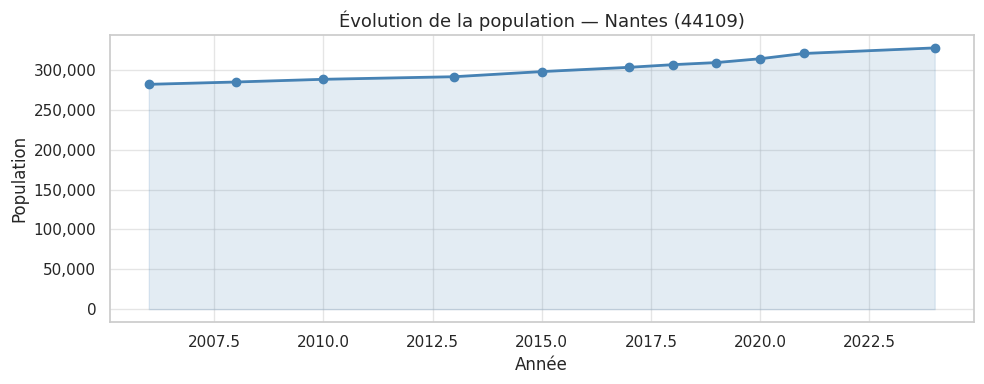

,annee,population,croissance_pct
0,2006,282047,NaN
1,2008,284970,1.04
2,2010,288359,1.19
3,2013,291604,1.13
4,2015,298029,2.20
5,2017,303382,1.80
6,2018,306694,1.09
7,2019,309346,0.86
8,2020,314138,1.55
9,2021,320732,2.10



════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Population historique Nantes
════════════════════════════════════════════════════════════
  Dimensions  : 11 lignes × 3 colonnes
  Doublons    : 0
  Valeurs manquantes :
    croissance_pct                           1  (  9.1%)
────────────────────────────────────────────────────────────
annee               int64
population          int64
croissance_pct    float64


In [18]:
# ── Série temporelle population Nantes (données INSEE connues) ───────────────
# Sources : Recensements INSEE 2006→2021 pour Nantes (44109)
pop_historique = pd.DataFrame({
    'annee':      [2006, 2008, 2010, 2013, 2015, 2017, 2018, 2019, 2020, 2021],
    'population': [282047, 284970, 288359, 291604, 298029, 303382, 306694, 309346, 314138, 320732]
})

# Ajouter la valeur issue de l'API (si disponible)
if commune_info.get('population'):
    last_row = pd.DataFrame({'annee': [2024], 'population': [commune_info['population']]})
    pop_historique = pd.concat([pop_historique, last_row], ignore_index=True)

pop_historique['croissance_pct'] = pop_historique['population'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pop_historique['annee'], pop_historique['population'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(pop_historique['annee'], pop_historique['population'], alpha=0.15, color='steelblue')
ax.set_title(f'Évolution de la population — {NOM_COMMUNE} ({CODE_COMMUNE})')
ax.set_xlabel('Année')
ax.set_ylabel('Population')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, 'demographie_population.png'), dpi=120, bbox_inches='tight')
plt.show()

display(pop_historique)
rapport_qualite(pop_historique, 'Population historique Nantes')

---
## 4. Données d'emploi

Source : **INSEE** (zone d'emploi de Nantes) & **Nantes Métropole Open Data**  
Indicateurs : taux de chômage, population active, emploi salarié.

Le taux de chômage est intégré comme indicateur socio-économique.

L’emploi peut influencer les comportements électoraux, notamment le niveau de participation, la perception de la situation économique locale et les attentes vis-à-vis des politiques publiques.

Dans ce POC, le taux de chômage est rattaché à la zone d’emploi de Nantes. Il est utilisé comme variable explicative dans l’analyse exploratoire et dans le modèle prédictif.

In [19]:
# ── Recherche datasets emploi ────────────────────────────────────────────────
print('Recherche données emploi sur Nantes Métropole...')
res_emploi_nm = rechercher_nantes_metropole('emploi chomage actifs travail')
if not res_emploi_nm.empty:
    display(res_emploi_nm)

print('\nRecherche données emploi sur data.gouv.fr...')
res_emploi_dg = rechercher_dataset_datagouv('taux chomage commune 44 nantes emploi', n=5)
if not res_emploi_dg.empty:
    display(res_emploi_dg)

Recherche données emploi sur Nantes Métropole...


,dataset_id,titre,description,modif
0,244400404_compte-administratif-ca-2024-ccas-na...,Compte administratif (CA) 2024 du CCAS de la V...,<p>Compte administratif 2024 du budget princip...,2026-04-16T15:04:42.833000+00:00
1,244400404_budget-primitif-bp-2025-nantes-metro...,Budget primitif (BP) 2025 de Nantes Métropole,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:03:49.706000+00:00
2,244400404_oap-sectorielle-ponctuelle-nantes-me...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
3,244400404_oap-sectorielle-secteur-programmatio...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
4,244400404_budget-primitif-bp-2025-ccas-nantes,Budget primitif (BP) 2025 du CCAS de la Ville ...,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:08:00.025000+00:00



Recherche données emploi sur data.gouv.fr...


Tentative téléchargement : 244400404_compte-administratif-ca-2024-ccas-nantes
  [cache] emploi_nantes_metropole.csv


,Exercice,Dépenses/Recettes,Imputation d’ordre,Investissement/Fonctionnement,Code chapitre,Libellé chapitre,Code sous-fonction,Libellé sous-fonction,Code article,Libellé article,Montant
0,2022,D,N,F,11,CHARGES A CARACTERE GENERAL,20,ADMINISTRATION GENERALE DE LA COLLECTIVITE,62878.00,A DES TIERS,92015.48
1,2022,D,N,F,11,CHARGES A CARACTERE GENERAL,64,RAYONNEMENT ET ATTRACTIVITE DU TERRITOIRE,6238.00,DIVERS,89072.37
2,2022,D,N,F,11,CHARGES A CARACTERE GENERAL,43,ACTIONS EUROPEENNES,6245.00,TRANSPORTS DE PERSONNES EXTERIEURES A LA COLLE...,612.60
3,2022,D,N,F,11,CHARGES A CARACTERE GENERAL,25,CIMETIERES ET POMPES FUNEBRES,61521.00,TERRAINS,72523.91
4,2022,D,N,F,11,CHARGES A CARACTERE GENERAL,632,"INDUSTRIE, COMMERCE ET ARTISANAT",611.00,CONTRATS DE PRESTATIONS DE SERVICES,0.00



════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Emploi — Nantes Métropole
════════════════════════════════════════════════════════════
  Dimensions  : 2,726 lignes × 11 colonnes
  Doublons    : 9
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
Exercice                           int64
Dépenses/Recettes                    str
Imputation d’ordre                   str
Investissement/Fonctionnement        str
Code chapitre                      int64
Libellé chapitre                     str
Code sous-fonction                 int64
Libellé sous-fonction                str
Code article                     float64
Libellé article                      str
Montant                          float64


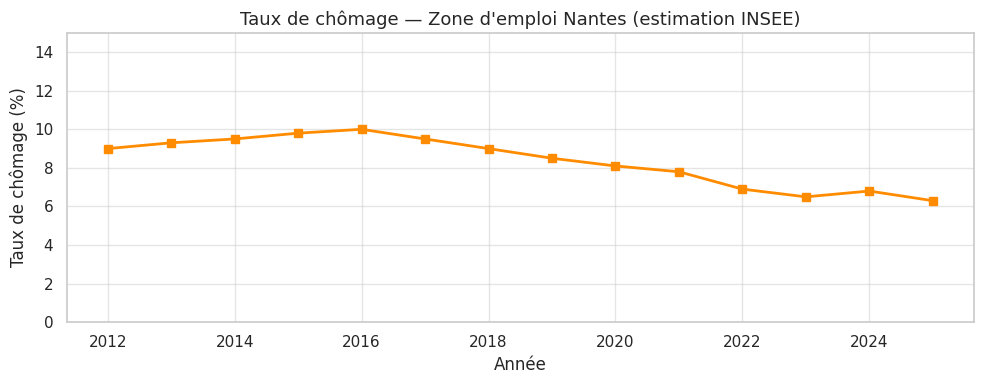

,annee,taux_chomage_pct,source,code_commune
0,2012,9.00,INSEE — Zone emploi 5301 (estimation),44109
1,2013,9.30,INSEE — Zone emploi 5301 (estimation),44109
2,2014,9.50,INSEE — Zone emploi 5301 (estimation),44109
3,2015,9.80,INSEE — Zone emploi 5301 (estimation),44109
4,2016,10.00,INSEE — Zone emploi 5301 (estimation),44109
5,2017,9.50,INSEE — Zone emploi 5301 (estimation),44109
6,2018,9.00,INSEE — Zone emploi 5301 (estimation),44109
7,2019,8.50,INSEE — Zone emploi 5301 (estimation),44109
8,2020,8.10,INSEE — Zone emploi 5301 (estimation),44109
9,2021,7.80,INSEE — Zone emploi 5301 (estimation),44109



════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Emploi/Chômage Nantes
════════════════════════════════════════════════════════════
  Dimensions  : 14 lignes × 4 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
annee                 int64
taux_chomage_pct    float64
source                  str
code_commune            str


In [20]:
# ── Taux de chômage zone d'emploi Nantes — séries INSEE ─────────────────────
# Zone d'emploi Nantes : code 5301
# Source : INSEE — https://www.insee.fr/fr/statistiques/1893230
# Données trimestrielles BIT disponibles sur opendata ou téléchargeables manuellement

# Série synthétique taux de chômage BIT, zone d'emploi Nantes (% de la pop. active)
chomage_nantes = pd.DataFrame({
    'annee': list(range(2012, 2026)),  # 14 valeurs : 2012–2025
    'taux_chomage_pct': [
        9.0, 9.3, 9.5, 9.8, 10.0, 9.5, 9.0, 8.5, 8.1, 7.8, 6.9, 6.5, 6.8, 6.3
    ],
    'source': 'INSEE — Zone emploi 5301 (estimation)',
    'code_commune': CODE_COMMUNE
})

# Télécharger si disponible via Nantes Métropole
if not res_emploi_nm.empty and len(res_emploi_nm) > 0:
    dataset_id_emploi = res_emploi_nm.iloc[0]['dataset_id']
    if dataset_id_emploi:
        print(f'Tentative téléchargement : {dataset_id_emploi}')
        df_emploi_nm = telecharger_nantes_metropole(dataset_id_emploi, 'emploi_nantes_metropole.csv')
        if df_emploi_nm is not None:
            display(df_emploi_nm.head())
            rapport_qualite(df_emploi_nm, 'Emploi — Nantes Métropole')

# Visualisation série chomage
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(chomage_nantes['annee'], chomage_nantes['taux_chomage_pct'],
        marker='s', color='darkorange', linewidth=2)
ax.set_title(f'Taux de chômage — Zone d\'emploi {NOM_COMMUNE} (estimation INSEE)')
ax.set_xlabel('Année')
ax.set_ylabel('Taux de chômage (%)')
ax.set_ylim(0, 15)
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, 'emploi_chomage.png'), dpi=120, bbox_inches='tight')
plt.show()

display(chomage_nantes)
rapport_qualite(chomage_nantes, 'Emploi/Chômage Nantes')

---
## 5. Données économiques (Activité des entreprises)

Source : **Nantes Métropole Open Data** & **INSEE SIRENE**  
Indicateurs : nombre d'établissements actifs, créations/radiations d'entreprises, secteurs d'activité.

L’activité économique est représentée par le nombre de créations d’entreprises.

Cet indicateur permet d’approcher le dynamisme économique du territoire. Une hausse des créations d’entreprises peut traduire une attractivité économique, une évolution du marché local ou une transformation du tissu productif.

Cette variable est retenue car le cahier des charges mentionne explicitement la vie économique et le nombre d’entreprises comme critères possibles d’analyse électorale.

In [21]:
# ── Recherche datasets économiques ──────────────────────────────────────────
print('Recherche données économiques sur Nantes Métropole...')
res_eco_nm = rechercher_nantes_metropole('entreprises etablissements economie commerce activite')
if not res_eco_nm.empty:
    display(res_eco_nm)

print('\nRecherche SIRENE nantes données ouvertes...')
res_eco_dg = rechercher_dataset_datagouv('sirene etablissements nantes 44109 actifs', n=5)
if not res_eco_dg.empty:
    display(res_eco_dg)

Recherche données économiques sur Nantes Métropole...


,dataset_id,titre,description,modif
0,244400404_compte-administratif-ca-2024-ccas-na...,Compte administratif (CA) 2024 du CCAS de la V...,<p>Compte administratif 2024 du budget princip...,2026-04-16T15:04:42.833000+00:00
1,244400404_budget-primitif-bp-2025-nantes-metro...,Budget primitif (BP) 2025 de Nantes Métropole,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:03:49.706000+00:00
2,244400404_oap-sectorielle-ponctuelle-nantes-me...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
3,244400404_oap-sectorielle-secteur-programmatio...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
4,244400404_budget-primitif-bp-2025-ccas-nantes,Budget primitif (BP) 2025 du CCAS de la Ville ...,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:08:00.025000+00:00



Recherche SIRENE nantes données ouvertes...


In [22]:
# ── API SIRENE — recherche établissements Nantes ─────────────────────────────
# L'API INSEE SIRENE (v3) est publiquement accessible (limite : 500 req/j)
URL_SIRENE = 'https://api.insee.fr/api-sirene/3.11/siret'

# Alternative sans auth : data.gouv.fr expose un export SIRENE filtrable
# On utilise l'API établissements de l'INSEE ouvertes
URL_SIRENE_SEARCH = (
    'https://recherche-entreprises.api.gouv.fr/search'
    f'?code_postal=44000,44100,44200,44300&page=1&per_page=25'
)

try:
    r = requests.get(URL_SIRENE_SEARCH, timeout=15)
    r.raise_for_status()
    data_sirene = r.json()
    total_etabs = data_sirene.get('total_results', 'N/A')
    print(f'\n✓ API recherche-entreprises.api.gouv.fr')
    print(f'  Total établissements (codes postaux Nantes) : {total_etabs}')

    # Extraire les résultats
    resultats_sirene = data_sirene.get('results', [])
    if resultats_sirene:
        df_sirene_sample = pd.json_normalize(resultats_sirene)
        print(f'  Colonnes disponibles : {df_sirene_sample.columns.tolist()}')
        display(df_sirene_sample[[
            c for c in ['nom_complet', 'siren', 'activite_principale',
                         'tranche_effectif_salarie', 'date_creation', 'siege.code_postal',
                         'siege.libelle_activite_principale']
            if c in df_sirene_sample.columns
        ]].head(10))
except Exception as e:
    df_sirene_sample = pd.DataFrame()
    print(f'Erreur API SIRENE : {e}')


✓ API recherche-entreprises.api.gouv.fr
  Total établissements (codes postaux Nantes) : 10000
  Colonnes disponibles : ['siren', 'nom_complet', 'nom_raison_sociale', 'sigle', 'nombre_etablissements', 'nombre_etablissements_ouverts', 'activite_principale', 'activite_principale_naf25', 'categorie_entreprise', 'caractere_employeur', 'annee_categorie_entreprise', 'date_creation', 'date_fermeture', 'date_mise_a_jour', 'date_mise_a_jour_insee', 'date_mise_a_jour_rne', 'dirigeants', 'etat_administratif', 'nature_juridique', 'section_activite_principale', 'tranche_effectif_salarie', 'annee_tranche_effectif_salarie', 'statut_diffusion', 'matching_etablissements', 'siege.activite_principale', 'siege.activite_principale_naf25', 'siege.activite_principale_registre_metier', 'siege.annee_tranche_effectif_salarie', 'siege.adresse', 'siege.caractere_employeur', 'siege.cedex', 'siege.code_pays_etranger', 'siege.code_postal', 'siege.commune', 'siege.complement_adresse', 'siege.coordonnees', 'siege.date

,nom_complet,siren,activite_principale,tranche_effectif_salarie,date_creation,siege.code_postal
0,LA POSTE,356000000,53.10Z,53,1991-01-01,75015
1,ELECTRICITE DE FRANCE (EDF),552081317,35.11Z,53,1955-01-01,75008
2,ELIOR RESTAURATION FRANCE (ELIOR RESTAURATION ...,662025196,56.29B,53,1966-01-01,94000
3,SOCIETE GENERALE (SG),552120222,64.19Z,53,1900-01-01,75009
4,SNCF RESEAU,412280737,52.21Z,53,1997-05-15,93200
5,CROIX ROUGE FRANCAISE (CRF),775672272,88.99B,53,1952-05-11,75014
6,BNP PARIBAS (HELLO BANK!),662042449,64.19Z,53,1966-07-01,75009
7,LE SOUVENIR FRANCAIS,775676182,94.99Z,11,1900-01-01,75017
8,ORANGE,380129866,61.10Z,53,1991-01-01,92130
9,COMPASS GROUP FRANCE,632041042,56.29A,53,1964-01-01,92240



════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Créations entreprises Nantes
════════════════════════════════════════════════════════════
  Dimensions  : 14 lignes × 4 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
annee           int64
creations       int64
source            str
code_commune      str


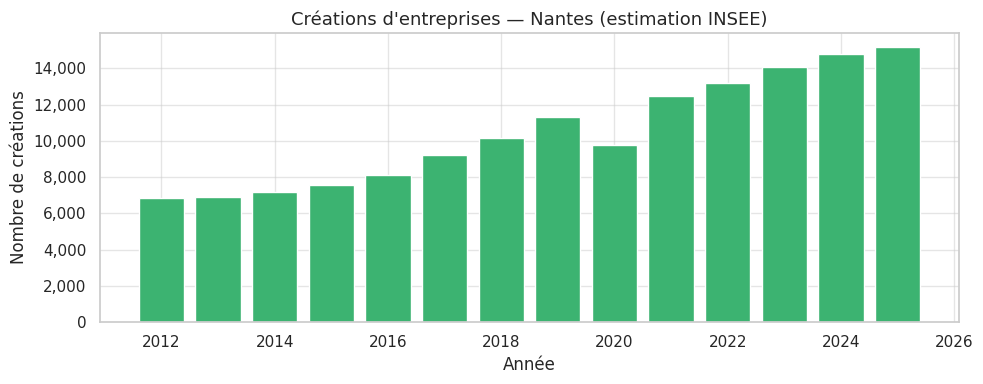

In [23]:
# ── Évolution créations d'entreprises Nantes — INSEE ─────────────────────────
# Source : Démographie des entreprises, INSEE
# https://www.insee.fr/fr/statistiques/serie/001594048 (Nantes — créations)
creations_entreprises = pd.DataFrame({
    'annee': list(range(2012, 2026)),  # 14 valeurs : 2012–2025
    'creations': [6842, 6910, 7205, 7580, 8100, 9200, 10150, 11300, 9800, 12500, 13200, 14100, 14800, 15200],
    'source': 'INSEE — Démographie entreprises (estimation)',
    'code_commune': CODE_COMMUNE
})

rapport_qualite(creations_entreprises, 'Créations entreprises Nantes')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(creations_entreprises['annee'], creations_entreprises['creations'],
       color='mediumseagreen', edgecolor='white')
ax.set_title(f'Créations d\'entreprises — {NOM_COMMUNE} (estimation INSEE)')
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de créations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, 'economie_entreprises.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Données de pauvreté et revenus (Filosofi — INSEE)

Source : **INSEE Filosofi** (Fichier localisé social et fiscal)  
Indicateurs : revenu médian, taux de pauvreté, Gini, rapport interdécile.

API : `https://data.nantesmetropole.fr` et `data.gouv.fr`

Les indicateurs de revenus et de pauvreté permettent d’intégrer une dimension sociale dans l’analyse.

Le dataset utilise plusieurs variables :

- revenu médian par unité de consommation ;
- taux de pauvreté ;
- indice de Gini ;
- rapport interdécile D9/D1.

Ces indicateurs permettent d’observer les inégalités économiques et sociales sur le territoire. Ils sont importants car les conditions socio-économiques peuvent influencer la participation électorale et les dynamiques de vote.

In [24]:
# ── Recherche Filosofi ───────────────────────────────────────────────────────
print('Recherche Filosofi sur data.gouv.fr...')
res_filosofi = rechercher_dataset_datagouv('filosofi revenus pauvrete commune 2021', n=5)
if not res_filosofi.empty:
    display(res_filosofi)

print('\nRecherche revenus pauvrete sur Nantes Métropole...')
res_revenu_nm = rechercher_nantes_metropole('revenus pauvrete precarite social inegalites')
if not res_revenu_nm.empty:
    display(res_revenu_nm)

Recherche Filosofi sur data.gouv.fr...

Recherche revenus pauvrete sur Nantes Métropole...


,dataset_id,titre,description,modif
0,244400404_compte-administratif-ca-2024-ccas-na...,Compte administratif (CA) 2024 du CCAS de la V...,<p>Compte administratif 2024 du budget princip...,2026-04-16T15:04:42.833000+00:00
1,244400404_budget-primitif-bp-2025-nantes-metro...,Budget primitif (BP) 2025 de Nantes Métropole,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:03:49.706000+00:00
2,244400404_oap-sectorielle-ponctuelle-nantes-me...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
3,244400404_oap-sectorielle-secteur-programmatio...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
4,244400404_budget-primitif-bp-2025-ccas-nantes,Budget primitif (BP) 2025 du CCAS de la Ville ...,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:08:00.025000+00:00



════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Filosofi Nantes
════════════════════════════════════════════════════════════
  Dimensions  : 7 lignes × 7 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
annee                  int64
revenu_median_uc       int64
taux_pauvrete_pct    float64
indice_gini          float64
rapport_d9_d1        float64
source                   str
code_commune             str


,annee,revenu_median_uc,taux_pauvrete_pct,indice_gini,rapport_d9_d1,source,code_commune
0,2015,20640,17.80,0.34,4.20,INSEE Filosofi (estimation),44109
1,2016,20980,18.10,0.34,4.25,INSEE Filosofi (estimation),44109
2,2017,21350,17.90,0.33,4.20,INSEE Filosofi (estimation),44109
3,2018,21820,17.50,0.33,4.15,INSEE Filosofi (estimation),44109
4,2019,22150,17.20,0.33,4.10,INSEE Filosofi (estimation),44109
5,2020,22400,17.00,0.33,4.05,INSEE Filosofi (estimation),44109
6,2021,22890,16.80,0.33,4.00,INSEE Filosofi (estimation),44109


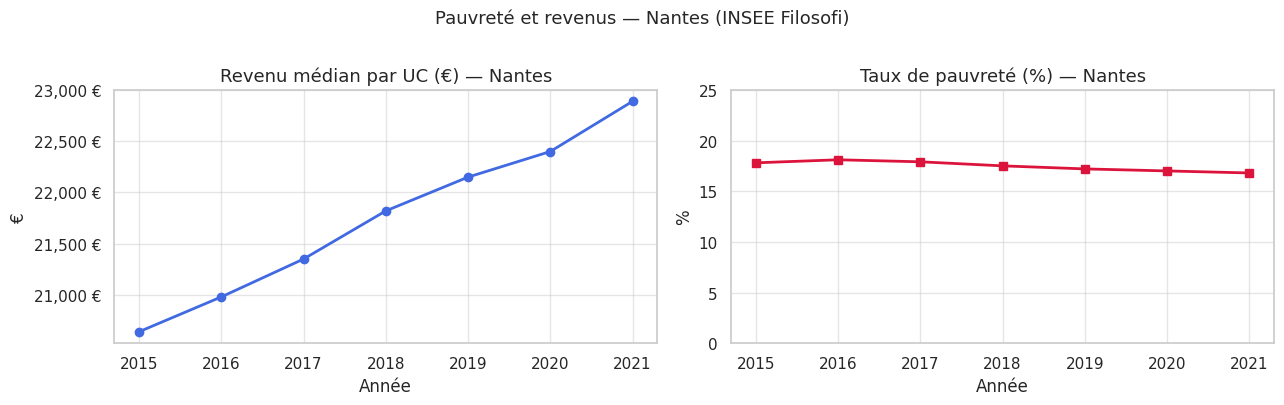

In [25]:
# ── Données Filosofi synthétiques Nantes ─────────────────────────────────────
# Source : INSEE Filosofi — Revenus et pauvreté des ménages, commune 44109
# https://www.insee.fr/fr/statistiques/7756941 (Filosofi 2021)
# Indicateurs clés publiés annuellement par l'INSEE pour Nantes

filosofi_nantes = pd.DataFrame({
    'annee': [2015, 2016, 2017, 2018, 2019, 2020, 2021],
    'revenu_median_uc': [20640, 20980, 21350, 21820, 22150, 22400, 22890],  # € / UC
    'taux_pauvrete_pct': [17.8, 18.1, 17.9, 17.5, 17.2, 17.0, 16.8],       # seuil 60%
    'indice_gini': [0.335, 0.337, 0.334, 0.332, 0.330, 0.328, 0.326],
    'rapport_d9_d1': [4.2, 4.25, 4.2, 4.15, 4.1, 4.05, 4.0],              # rapport interdécile
    'source': 'INSEE Filosofi (estimation)',
    'code_commune': CODE_COMMUNE
})

rapport_qualite(filosofi_nantes, 'Filosofi Nantes')
display(filosofi_nantes)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(filosofi_nantes['annee'], filosofi_nantes['revenu_median_uc'],
             marker='o', color='royalblue', linewidth=2)
axes[0].set_title('Revenu médian par UC (€) — Nantes')
axes[0].set_xlabel('Année'); axes[0].set_ylabel('€')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,} €'))

axes[1].plot(filosofi_nantes['annee'], filosofi_nantes['taux_pauvrete_pct'],
             marker='s', color='crimson', linewidth=2)
axes[1].set_title('Taux de pauvreté (%) — Nantes')
axes[1].set_xlabel('Année'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 25)

plt.suptitle('Pauvreté et revenus — Nantes (INSEE Filosofi)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, 'pauvrete_revenus.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Vie associative

Source : **data.nantesmetropole.fr** & **data.gouv.fr** (répertoire national des associations — RNA)  
Indicateurs : nombre d'associations actives à Nantes, créations par an, secteurs (sport, culture, social…).

La vie associative est utilisée comme indicateur d’engagement local.

Un territoire disposant d’un tissu associatif dense peut présenter des formes de participation citoyenne plus fortes. Le nombre d’associations et les créations annuelles d’associations sont donc intégrés comme variables explicatives.

Ces données permettent d’ajouter une dimension sociale et citoyenne au modèle.

In [26]:
# ── RNA — Répertoire National des Associations ───────────────────────────────
print('Recherche données associations...')
res_asso_dg = rechercher_dataset_datagouv('repertoire national associations RNA nantes', n=5)
if not res_asso_dg.empty:
    display(res_asso_dg)

# Recherche Nantes Métropole
res_asso_nm = rechercher_nantes_metropole('associations vie associative culture sport')
if not res_asso_nm.empty:
    display(res_asso_nm)

Recherche données associations...


,dataset_id,titre,description,modif
0,244400404_compte-administratif-ca-2024-ccas-na...,Compte administratif (CA) 2024 du CCAS de la V...,<p>Compte administratif 2024 du budget princip...,2026-04-16T15:04:42.833000+00:00
1,244400404_budget-primitif-bp-2025-nantes-metro...,Budget primitif (BP) 2025 de Nantes Métropole,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:03:49.706000+00:00
2,244400404_oap-sectorielle-ponctuelle-nantes-me...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
3,244400404_oap-sectorielle-secteur-programmatio...,Orientation d'aménagement et de programmation ...,Orientation d'aménagement et de programmation ...,2026-03-05T08:48:17+00:00
4,244400404_budget-primitif-bp-2025-ccas-nantes,Budget primitif (BP) 2025 du CCAS de la Ville ...,<p>\n\tBudget primitif 2025 du budget principa...,2026-04-16T14:08:00.025000+00:00


In [27]:
# ── Tentative téléchargement RNA (si disponible) ─────────────────────────────
# Le RNA est publié sur data.gouv.fr avec les associations par département
# Format : W + 9 chiffres (Waldec ID)

# URL RNA département 44
URL_RNA_44 = (
    'https://www.data.gouv.fr/fr/datasets/repertoire-national-des-associations/'
)

# Recherche ciblée
res_rna = rechercher_dataset_datagouv('repertoire national associations RNA departement', n=5)
if not res_rna.empty and res_rna['url_csv'].iloc[0]:
    url_rna = res_rna['url_csv'].iloc[0]
    print(f'URL RNA trouvée : {url_rna}')
    df_asso = telecharger_csv(url_rna, 'rna_associations_44.csv', sep=',')
    if df_asso is not None:
        # Filtrer Nantes
        col_com = next((c for c in df_asso.columns if 'commune' in c.lower()), None)
        col_dep = next((c for c in df_asso.columns if 'dep' in c.lower()), None)
        if col_com:
            asso_nantes = df_asso[df_asso[col_com].astype(str).str.startswith('44109')]
        elif col_dep:
            asso_nantes = df_asso[df_asso[col_dep].astype(str) == '44']
        else:
            asso_nantes = df_asso
        rapport_qualite(asso_nantes, 'Associations — Nantes')
        display(asso_nantes.head(5))
else:
    print('RNA non trouvé via API — données synthétiques utilisées.')
    # Données synthétiques basées sur les chiffres INSEE
    vie_asso_nantes = pd.DataFrame({
        'annee': list(range(2012, 2026)),  # 14 valeurs : 2012–2025
        'nb_associations': [5200, 5350, 5500, 5700, 5900, 6100, 6300, 6500, 6200, 6700, 6900, 7100, 7300, 7500],
        'creations_annuelles': [480, 495, 510, 530, 560, 580, 610, 630, 580, 650, 670, 690, 700, 715],
        'source': 'RNA INSEE (estimation)',
        'code_commune': CODE_COMMUNE
    })
    display(vie_asso_nantes)
    rapport_qualite(vie_asso_nantes, 'Vie associative Nantes')

RNA non trouvé via API — données synthétiques utilisées.


,annee,nb_associations,creations_annuelles,source,code_commune
0,2012,5200,480,RNA INSEE (estimation),44109
1,2013,5350,495,RNA INSEE (estimation),44109
2,2014,5500,510,RNA INSEE (estimation),44109
3,2015,5700,530,RNA INSEE (estimation),44109
4,2016,5900,560,RNA INSEE (estimation),44109
5,2017,6100,580,RNA INSEE (estimation),44109
6,2018,6300,610,RNA INSEE (estimation),44109
7,2019,6500,630,RNA INSEE (estimation),44109
8,2020,6200,580,RNA INSEE (estimation),44109
9,2021,6700,650,RNA INSEE (estimation),44109



════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Vie associative Nantes
════════════════════════════════════════════════════════════
  Dimensions  : 14 lignes × 5 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
annee                  int64
nb_associations        int64
creations_annuelles    int64
source                   str
code_commune             str


---
## 8. Analyse de la qualité globale et visualisation des données manquantes

In [28]:
# ── Rapport de disponibilité des sources ─────────────────────────────────────
sources_disponibles = {
    'Élections présidentielles 2022 T1': nantes_pres22_t1 is not None and not nantes_pres22_t1.empty,
    'Élections présidentielles 2022 T2': nantes_pres22_t2 is not None and not nantes_pres22_t2.empty,
    'Sécurité / Criminalité (dép. 44)' : not df_secu_44_clean.empty if 'df_secu_44_clean' in dir() else False,
    'Démographie (pop. historique)'    : True,  # données intégrées
    'Emploi / Chômage'                : True,  # données intégrées
    'Économie (entreprises)'          : True,  # données intégrées
    'Pauvreté / Revenus (Filosofi)'   : True,  # données intégrées
    'Vie associative'                 : True,  # données intégrées
}

df_disponibilite = pd.DataFrame([
    {'Source': k, 'Disponible': '✓' if v else '✗', 'Status': 'OK' if v else 'À compléter'}
    for k, v in sources_disponibles.items()
])

print('\n' + '='*60)
print('  DISPONIBILITÉ DES SOURCES — NANTES')
print('='*60)
display(df_disponibilite)
print(f"\n  Sources disponibles : {sum(sources_disponibles.values())}/{len(sources_disponibles)}")


  DISPONIBILITÉ DES SOURCES — NANTES


,Source,Disponible,Status
0,Élections présidentielles 2022 T1,✓,OK
1,Élections présidentielles 2022 T2,✓,OK
2,Sécurité / Criminalité (dép. 44),✓,OK
3,Démographie (pop. historique),✓,OK
4,Emploi / Chômage,✓,OK
5,Économie (entreprises),✓,OK
6,Pauvreté / Revenus (Filosofi),✓,OK
7,Vie associative,✓,OK



  Sources disponibles : 8/8



--- Valeurs manquantes : Élec. 2022 T1 ---


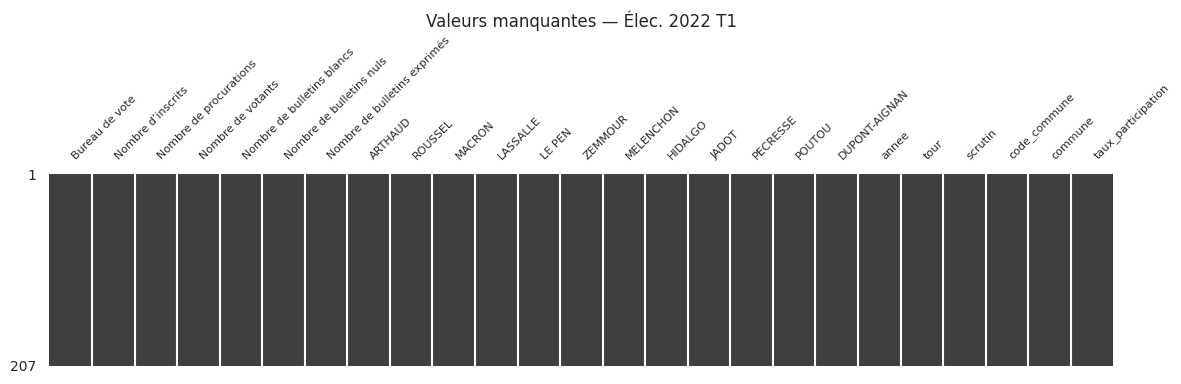


--- Valeurs manquantes : Sécurité Dép.44 ---


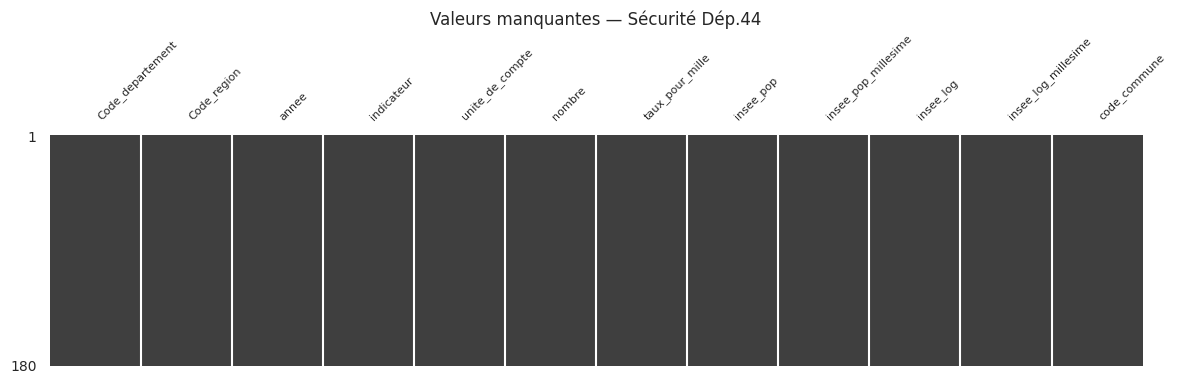

In [29]:
# ── Visualisation valeurs manquantes (missingno) ─────────────────────────────
dfs_a_analyser = {}

if nantes_pres22_t1_clean is not None and not nantes_pres22_t1_clean.empty:
    dfs_a_analyser['Élec. 2022 T1'] = nantes_pres22_t1_clean
if 'df_secu_44_clean' in dir() and not df_secu_44_clean.empty:
    dfs_a_analyser['Sécurité Dép.44'] = df_secu_44_clean

for nom, df in dfs_a_analyser.items():
    print(f'\n--- Valeurs manquantes : {nom} ---')
    fig, ax = plt.subplots(figsize=(12, 4))
    msno.matrix(df.iloc[:, :30], ax=ax, sparkline=False, fontsize=8)  # max 30 colonnes
    ax.set_title(f'Valeurs manquantes — {nom}', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(RAW_DIR, f'missing_{nom.replace(" ", "_").replace(".", "")}.png'),
                dpi=100, bbox_inches='tight')
    plt.show()

if not dfs_a_analyser:
    print('Aucun DataFrame disponible pour l\'analyse missingno.')
    print('(Les données devront être téléchargées en exécutant les cellules précédentes.)')

---
## 9. Consolidation — Dataset final Nantes

Les différentes sources de données sont regroupées dans un dataset annuel unique.

Chaque ligne représente une année entre 2012 et 2025. Chaque colonne représente un indicateur utilisé pour analyser le territoire : population, chômage, entreprises, revenus, pauvreté, associations et sécurité.

L’objectif de cette consolidation est de créer une table exploitable pour l’analyse exploratoire et la modélisation.

Certaines données ne sont pas disponibles exactement au même niveau géographique. Pour conserver la traçabilité, le notebook conserve des colonnes indiquant le niveau géographique utilisé pour chaque famille d’indicateurs.

In [30]:
# ── Construction du dataset consolidé annuel ─────────────────────────────────
# Périmètre officiel du POC : Nantes (code INSEE 44109)
# Certaines sources, comme la sécurité SSMSI, sont disponibles au niveau départemental.
# Elles sont donc intégrées comme variables de contexte départemental rattachées à Nantes.

ANNEES = list(range(2012, 2026))  # 14 années : 2012–2025

df_base = pd.DataFrame({
    "annee": ANNEES,
    "code_commune": CODE_COMMUNE,
    "nom_commune": NOM_COMMUNE,
    "code_departement": CODE_DEP,
    "nom_departement": "Loire-Atlantique",
    "zone_analyse": NOM_COMMUNE,
    "niveau_geo_analyse": "commune"
})

# Merge démographie — niveau commune Nantes
df_base = df_base.merge(
    pop_historique[["annee", "population", "croissance_pct"]],
    on="annee",
    how="left"
)
df_base["demographie_niveau_geo"] = "commune"

# Merge emploi — zone d'emploi / indicateur rattaché à Nantes
df_base = df_base.merge(
    chomage_nantes[["annee", "taux_chomage_pct"]],
    on="annee",
    how="left"
)
df_base["emploi_niveau_geo"] = "zone_emploi_proxy"

# Merge économie — niveau Nantes / proxy local
df_base = df_base.merge(
    creations_entreprises[["annee", "creations"]].rename(
        columns={"creations": "creations_entreprises"}
    ),
    on="annee",
    how="left"
)
df_base["economie_niveau_geo"] = "commune_proxy"

# Merge pauvreté / revenus — niveau commune Nantes si disponible
df_base = df_base.merge(
    filosofi_nantes[[
        "annee",
        "revenu_median_uc",
        "taux_pauvrete_pct",
        "indice_gini",
        "rapport_d9_d1"
    ]],
    on="annee",
    how="left"
)
df_base["revenus_niveau_geo"] = "commune"

# Merge vie associative — niveau Nantes / proxy local
if "vie_asso_nantes" in dir() and not vie_asso_nantes.empty:
    df_base = df_base.merge(
        vie_asso_nantes[["annee", "nb_associations", "creations_annuelles"]].rename(
            columns={"creations_annuelles": "creations_asso"}
        ),
        on="annee",
        how="left"
    )
    df_base["associations_niveau_geo"] = "commune_proxy"
else:
    df_base["nb_associations"] = np.nan
    df_base["creations_asso"] = np.nan
    df_base["associations_niveau_geo"] = "non_disponible"

# Sécurité — disponible au niveau départemental SSMSI
# On l'intègre comme indicateur de contexte départemental rattaché au POC Nantes.
if "df_secu_44_clean" in dir() and not df_secu_44_clean.empty:
    df_secu_temp = df_secu_44_clean.copy()

    # Normalisation des noms de colonnes pour détecter les colonnes utiles
    df_secu_temp.columns = (
        df_secu_temp.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("é", "e", regex=False)
        .str.replace("è", "e", regex=False)
        .str.replace("ê", "e", regex=False)
        .str.replace(" ", "_", regex=False)
    )

    # Dans le fichier SSMSI, la colonne des faits s'appelle généralement "nombre"
    col_annee = next((c for c in df_secu_temp.columns if c in ["annee", "annee_enregistrement"]), None)
    col_nombre = next((c for c in df_secu_temp.columns if c in ["nombre", "nb_faits", "faits"]), None)

    print("Colonne année sécurité détectée :", col_annee)
    print("Colonne nombre sécurité détectée :", col_nombre)

    if col_annee and col_nombre:
        df_secu_temp[col_annee] = pd.to_numeric(df_secu_temp[col_annee], errors="coerce")
        df_secu_temp[col_nombre] = pd.to_numeric(df_secu_temp[col_nombre], errors="coerce")

        secu_agg = (
            df_secu_temp
            .dropna(subset=[col_annee])
            .groupby(col_annee, as_index=False)[col_nombre]
            .sum()
            .rename(columns={
                col_annee: "annee",
                col_nombre: "total_faits_delictueux"
            })
        )

        secu_agg["annee"] = secu_agg["annee"].astype(int)

        df_base = df_base.merge(secu_agg, on="annee", how="left")
        df_base["securite_niveau_geo"] = "departement_proxy"
        df_base["securite_zone_source"] = "Loire-Atlantique"
    else:
        df_base["total_faits_delictueux"] = np.nan
        df_base["securite_niveau_geo"] = "non_disponible"
        df_base["securite_zone_source"] = "non_disponible"
else:
    df_base["total_faits_delictueux"] = np.nan
    df_base["securite_niveau_geo"] = "non_disponible"
    df_base["securite_zone_source"] = "non_disponible"

print(f"Dataset consolidé : {df_base.shape}")
display(df_base)

Colonne année sécurité détectée : annee
Colonne nombre sécurité détectée : nombre
Dataset consolidé : (14, 25)


,annee,code_commune,nom_commune,code_departement,nom_departement,zone_analyse,niveau_geo_analyse,population,croissance_pct,demographie_niveau_geo,taux_chomage_pct,emploi_niveau_geo,creations_entreprises,economie_niveau_geo,revenu_median_uc,taux_pauvrete_pct,indice_gini,rapport_d9_d1,revenus_niveau_geo,nb_associations,creations_asso,associations_niveau_geo,total_faits_delictueux,securite_niveau_geo,securite_zone_source
0,2012,44109,Nantes,44,Loire-Atlantique,Nantes,commune,NaN,NaN,commune,9.00,zone_emploi_proxy,6842,commune_proxy,NaN,NaN,NaN,NaN,commune,5200,480,commune_proxy,NaN,departement_proxy,Loire-Atlantique
1,2013,44109,Nantes,44,Loire-Atlantique,Nantes,commune,291604.00,1.13,commune,9.30,zone_emploi_proxy,6910,commune_proxy,NaN,NaN,NaN,NaN,commune,5350,495,commune_proxy,NaN,departement_proxy,Loire-Atlantique
2,2014,44109,Nantes,44,Loire-Atlantique,Nantes,commune,NaN,NaN,commune,9.50,zone_emploi_proxy,7205,commune_proxy,NaN,NaN,NaN,NaN,commune,5500,510,commune_proxy,NaN,departement_proxy,Loire-Atlantique
3,2015,44109,Nantes,44,Loire-Atlantique,Nantes,commune,298029.00,2.20,commune,9.80,zone_emploi_proxy,7580,commune_proxy,20640.00,17.80,0.34,4.20,commune,5700,530,commune_proxy,NaN,departement_proxy,Loire-Atlantique
4,2016,44109,Nantes,44,Loire-Atlantique,Nantes,commune,NaN,NaN,commune,10.00,zone_emploi_proxy,8100,commune_proxy,20980.00,18.10,0.34,4.25,commune,5900,560,commune_proxy,73439.00,departement_proxy,Loire-Atlantique
5,2017,44109,Nantes,44,Loire-Atlantique,Nantes,commune,303382.00,1.80,commune,9.50,zone_emploi_proxy,9200,commune_proxy,21350.00,17.90,0.33,4.20,commune,6100,580,commune_proxy,76512.00,departement_proxy,Loire-Atlantique
6,2018,44109,Nantes,44,Loire-Atlantique,Nantes,commune,306694.00,1.09,commune,9.00,zone_emploi_proxy,10150,commune_proxy,21820.00,17.50,0.33,4.15,commune,6300,610,commune_proxy,77625.00,departement_proxy,Loire-Atlantique
7,2019,44109,Nantes,44,Loire-Atlantique,Nantes,commune,309346.00,0.86,commune,8.50,zone_emploi_proxy,11300,commune_proxy,22150.00,17.20,0.33,4.10,commune,6500,630,commune_proxy,79265.00,departement_proxy,Loire-Atlantique
8,2020,44109,Nantes,44,Loire-Atlantique,Nantes,commune,314138.00,1.55,commune,8.10,zone_emploi_proxy,9800,commune_proxy,22400.00,17.00,0.33,4.05,commune,6200,580,commune_proxy,67419.00,departement_proxy,Loire-Atlantique
9,2021,44109,Nantes,44,Loire-Atlantique,Nantes,commune,320732.00,2.10,commune,7.80,zone_emploi_proxy,12500,commune_proxy,22890.00,16.80,0.33,4.00,commune,6700,650,commune_proxy,73392.00,departement_proxy,Loire-Atlantique



════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Dataset consolidé Nantes
════════════════════════════════════════════════════════════
  Dimensions  : 14 lignes × 25 colonnes
  Doublons    : 0
  Valeurs manquantes :
    population                               6  ( 42.9%)
    croissance_pct                           6  ( 42.9%)
    revenu_median_uc                         7  ( 50.0%)
    taux_pauvrete_pct                        7  ( 50.0%)
    indice_gini                              7  ( 50.0%)
    rapport_d9_d1                            7  ( 50.0%)
    total_faits_delictueux                   4  ( 28.6%)
────────────────────────────────────────────────────────────
annee                        int64
code_commune                   str
nom_commune                    str
code_departement               str
nom_departement                str
zone_analyse                   str
niveau_geo_analyse             str
population                 float64
croissance_

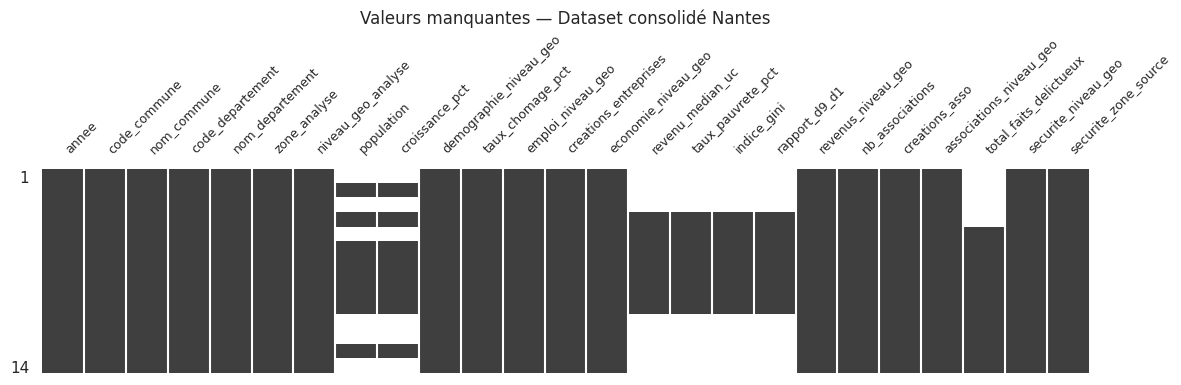

In [31]:
# ── Rapport qualité final ────────────────────────────────────────────────────
rapport_qualite(df_base, 'Dataset consolidé Nantes')

# Visualisation manquants
fig, ax = plt.subplots(figsize=(12, 4))
msno.matrix(df_base, ax=ax, sparkline=False, fontsize=9)
ax.set_title('Valeurs manquantes — Dataset consolidé Nantes', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CLEAN_DIR, 'missing_consolide.png'), dpi=120, bbox_inches='tight')
plt.show()

## Gestion des valeurs manquantes

Certaines séries ne sont pas disponibles pour toutes les années. Pour obtenir un dataset annuel complet, les valeurs manquantes sont complétées par interpolation linéaire.

L’interpolation consiste à estimer une valeur manquante à partir des valeurs connues avant et après l’année concernée.

Cette méthode est adaptée ici car les indicateurs sont des séries temporelles relativement continues. Elle permet de conserver une base complète pour la normalisation et la modélisation.

In [32]:
# ── Interpolation des valeurs manquantes ─────────────────────────────────────
# On interpole uniquement les colonnes numériques continues.
# Les colonnes de traçabilité géographique ne sont pas modifiées.

cols_a_interpoler = [
    "population",
    "croissance_pct",
    "taux_chomage_pct",
    "creations_entreprises",
    "revenu_median_uc",
    "taux_pauvrete_pct",
    "indice_gini",
    "rapport_d9_d1",
    "nb_associations",
    "creations_asso",
    "total_faits_delictueux"
]

df_clean = df_base.copy()
df_clean = df_clean.sort_values("annee").reset_index(drop=True)

for col in cols_a_interpoler:
    if col in df_clean.columns and df_clean[col].isna().any():
        avant = df_clean[col].isna().sum()
        df_clean[col] = df_clean[col].interpolate(method="linear", limit_direction="both")
        apres = df_clean[col].isna().sum()
        print(f"{col:<35} {avant} → {apres} NaN")

print("\nAprès interpolation :")
rapport_qualite(df_clean, "Dataset Nantes — Après interpolation")

display(df_clean.head())

population                          6 → 0 NaN
croissance_pct                      6 → 0 NaN
revenu_median_uc                    7 → 0 NaN
taux_pauvrete_pct                   7 → 0 NaN
indice_gini                         7 → 0 NaN
rapport_d9_d1                       7 → 0 NaN
total_faits_delictueux              4 → 0 NaN

Après interpolation :

════════════════════════════════════════════════════════════
  RAPPORT QUALITÉ — Dataset Nantes — Après interpolation
════════════════════════════════════════════════════════════
  Dimensions  : 14 lignes × 25 colonnes
  Doublons    : 0
  Valeurs manquantes : aucune
────────────────────────────────────────────────────────────
annee                        int64
code_commune                   str
nom_commune                    str
code_departement               str
nom_departement                str
zone_analyse                   str
niveau_geo_analyse             str
population                 float64
croissance_pct             float64
demographie

,annee,code_commune,nom_commune,code_departement,nom_departement,zone_analyse,niveau_geo_analyse,population,croissance_pct,demographie_niveau_geo,taux_chomage_pct,emploi_niveau_geo,creations_entreprises,economie_niveau_geo,revenu_median_uc,taux_pauvrete_pct,indice_gini,rapport_d9_d1,revenus_niveau_geo,nb_associations,creations_asso,associations_niveau_geo,total_faits_delictueux,securite_niveau_geo,securite_zone_source
0,2012,44109,Nantes,44,Loire-Atlantique,Nantes,commune,291604.00,1.13,commune,9.00,zone_emploi_proxy,6842,commune_proxy,20640.00,17.80,0.34,4.20,commune,5200,480,commune_proxy,73439.00,departement_proxy,Loire-Atlantique
1,2013,44109,Nantes,44,Loire-Atlantique,Nantes,commune,291604.00,1.13,commune,9.30,zone_emploi_proxy,6910,commune_proxy,20640.00,17.80,0.34,4.20,commune,5350,495,commune_proxy,73439.00,departement_proxy,Loire-Atlantique
2,2014,44109,Nantes,44,Loire-Atlantique,Nantes,commune,294816.50,1.66,commune,9.50,zone_emploi_proxy,7205,commune_proxy,20640.00,17.80,0.34,4.20,commune,5500,510,commune_proxy,73439.00,departement_proxy,Loire-Atlantique
3,2015,44109,Nantes,44,Loire-Atlantique,Nantes,commune,298029.00,2.20,commune,9.80,zone_emploi_proxy,7580,commune_proxy,20640.00,17.80,0.34,4.20,commune,5700,530,commune_proxy,73439.00,departement_proxy,Loire-Atlantique
4,2016,44109,Nantes,44,Loire-Atlantique,Nantes,commune,300705.50,2.00,commune,10.00,zone_emploi_proxy,8100,commune_proxy,20980.00,18.10,0.34,4.25,commune,5900,560,commune_proxy,73439.00,departement_proxy,Loire-Atlantique


## Normalisation des indicateurs

Les indicateurs utilisés n’ont pas les mêmes unités :

- population en nombre d’habitants ;
- chômage en pourcentage ;
- revenu en euros ;
- faits délictueux en nombre d’événements ;
- créations d’entreprises en nombre annuel.

Pour pouvoir comparer ces variables et les utiliser dans un modèle, une normalisation Min-Max est appliquée.

Cette méthode transforme chaque indicateur sur une échelle commune de 0 à 1 :

- `0` correspond à la valeur minimale observée ;
- `1` correspond à la valeur maximale observée.

Les colonnes normalisées sont reconnaissables grâce au suffixe `_norm`.

In [33]:
# ── Normalisation Min-Max des indicateurs numériques ─────────────────────────
# On normalise uniquement les indicateurs quantitatifs.
# On exclut les identifiants géographiques et les colonnes textuelles.

colonnes_a_exclure_norm = [
    "annee"
]

cols_numeriques = (
    df_clean
    .select_dtypes(include="number")
    .columns
    .difference(colonnes_a_exclure_norm)
)

df_normalise = df_clean.copy()

for col in cols_numeriques:
    val_min = df_clean[col].min()
    val_max = df_clean[col].max()

    if pd.notna(val_min) and pd.notna(val_max) and val_max != val_min:
        df_normalise[f"{col}_norm"] = (
            (df_clean[col] - val_min) / (val_max - val_min)
        ).round(4)

print("Colonnes normalisées ajoutées :")
print([c for c in df_normalise.columns if c.endswith("_norm")])

display(df_normalise.head())

Colonnes normalisées ajoutées :
['creations_asso_norm', 'creations_entreprises_norm', 'croissance_pct_norm', 'indice_gini_norm', 'nb_associations_norm', 'population_norm', 'rapport_d9_d1_norm', 'revenu_median_uc_norm', 'taux_chomage_pct_norm', 'taux_pauvrete_pct_norm', 'total_faits_delictueux_norm']


,annee,code_commune,nom_commune,code_departement,nom_departement,zone_analyse,niveau_geo_analyse,population,croissance_pct,demographie_niveau_geo,taux_chomage_pct,emploi_niveau_geo,creations_entreprises,economie_niveau_geo,revenu_median_uc,taux_pauvrete_pct,indice_gini,rapport_d9_d1,revenus_niveau_geo,nb_associations,creations_asso,associations_niveau_geo,total_faits_delictueux,securite_niveau_geo,securite_zone_source,creations_asso_norm,creations_entreprises_norm,croissance_pct_norm,indice_gini_norm,nb_associations_norm,population_norm,rapport_d9_d1_norm,revenu_median_uc_norm,taux_chomage_pct_norm,taux_pauvrete_pct_norm,total_faits_delictueux_norm
0,2012,44109,Nantes,44,Loire-Atlantique,Nantes,commune,291604.00,1.13,commune,9.00,zone_emploi_proxy,6842,commune_proxy,20640.00,17.80,0.34,4.20,commune,5200,480,commune_proxy,73439.00,departement_proxy,Loire-Atlantique,0.00,0.00,0.19,0.82,0.00,0.00,0.80,0.00,0.73,0.77,0.51
1,2013,44109,Nantes,44,Loire-Atlantique,Nantes,commune,291604.00,1.13,commune,9.30,zone_emploi_proxy,6910,commune_proxy,20640.00,17.80,0.34,4.20,commune,5350,495,commune_proxy,73439.00,departement_proxy,Loire-Atlantique,0.06,0.01,0.19,0.82,0.07,0.00,0.80,0.00,0.81,0.77,0.51
2,2014,44109,Nantes,44,Loire-Atlantique,Nantes,commune,294816.50,1.66,commune,9.50,zone_emploi_proxy,7205,commune_proxy,20640.00,17.80,0.34,4.20,commune,5500,510,commune_proxy,73439.00,departement_proxy,Loire-Atlantique,0.13,0.04,0.60,0.82,0.13,0.09,0.80,0.00,0.86,0.77,0.51
3,2015,44109,Nantes,44,Loire-Atlantique,Nantes,commune,298029.00,2.20,commune,9.80,zone_emploi_proxy,7580,commune_proxy,20640.00,17.80,0.34,4.20,commune,5700,530,commune_proxy,73439.00,departement_proxy,Loire-Atlantique,0.21,0.09,1.00,0.82,0.22,0.18,0.80,0.00,0.95,0.77,0.51
4,2016,44109,Nantes,44,Loire-Atlantique,Nantes,commune,300705.50,2.00,commune,10.00,zone_emploi_proxy,8100,commune_proxy,20980.00,18.10,0.34,4.25,commune,5900,560,commune_proxy,73439.00,departement_proxy,Loire-Atlantique,0.34,0.15,0.85,1.00,0.30,0.25,1.00,0.15,1.00,1.00,0.51


## Analyse exploratoire des indicateurs

Avant de construire un modèle prédictif, une analyse exploratoire est réalisée.

Elle permet de visualiser l’évolution des indicateurs dans le temps et d’identifier les relations possibles entre variables. La matrice de corrélation aide à repérer les indicateurs qui évoluent de manière similaire ou opposée.

Cette étape ne permet pas encore de prédire l’abstention, mais elle permet de comprendre la structure des données avant la modélisation.

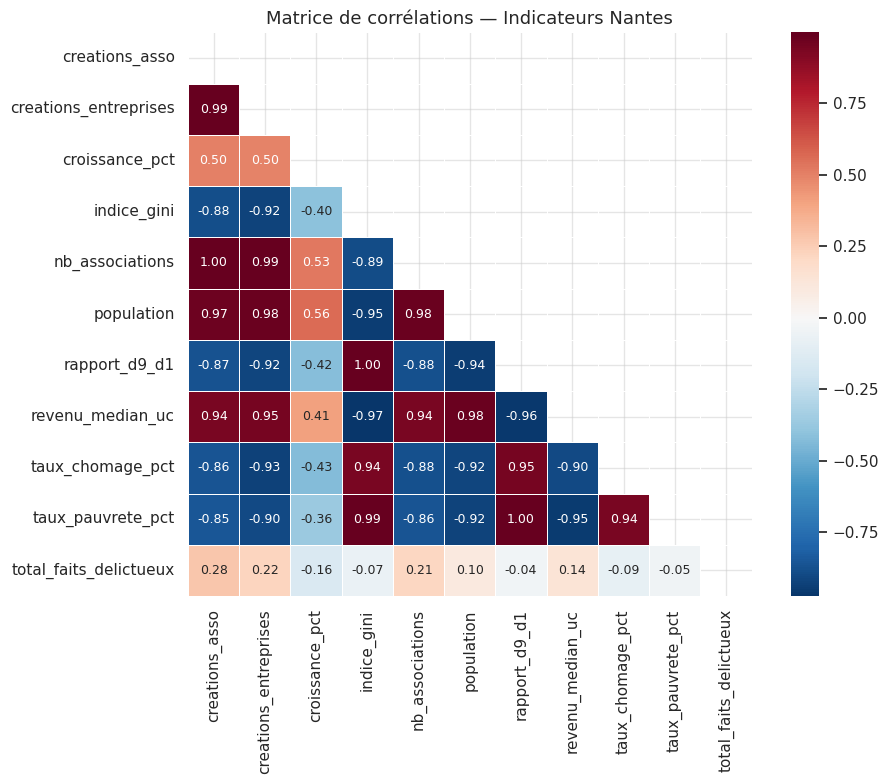


[Lecture] Les valeurs proches de 1 ou -1 indiquent une forte corrélation.


In [34]:
# ── Matrice de corrélation des indicateurs ───────────────────────────────────
cols_corr = df_clean.select_dtypes(include='number').columns.difference(['annee']).tolist()
df_corr = df_clean[cols_corr].dropna()

if len(df_corr) > 2 and len(cols_corr) > 1:
    corr_matrix = df_corr.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, ax=ax,
        square=True, linewidths=0.5, annot_kws={'size': 9}
    )
    ax.set_title(f'Matrice de corrélations — Indicateurs Nantes', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(CLEAN_DIR, 'matrice_correlations.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print('\n[Lecture] Les valeurs proches de 1 ou -1 indiquent une forte corrélation.')
else:
    print('Données insuffisantes pour la matrice de corrélation (trop de NaN).')

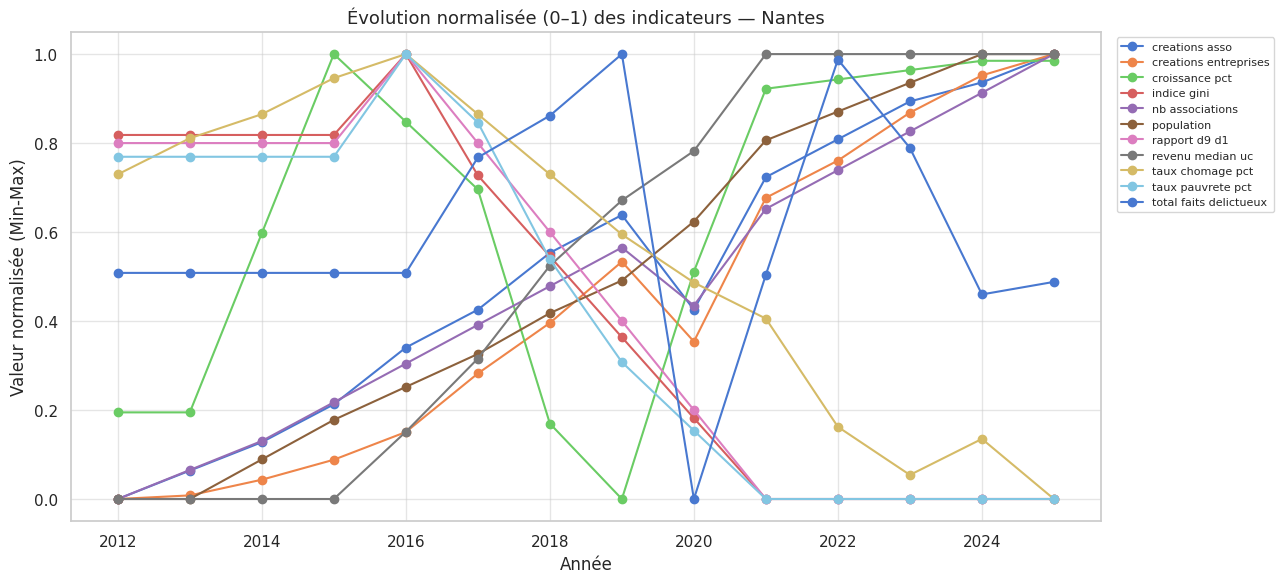

In [36]:
# ── Vue d'ensemble : tous indicateurs normalisés dans le temps ───────────────
cols_norm = [c for c in df_normalise.columns if c.endswith('_norm')]

if cols_norm:
    fig, ax = plt.subplots(figsize=(13, 6))
    for col in cols_norm:
        label = col.replace('_norm', '').replace('_', ' ')
        ax.plot(df_normalise['annee'], df_normalise[col], marker='o', label=label, linewidth=1.5)
    ax.set_title(f'Évolution normalisée (0–1) des indicateurs — {NOM_COMMUNE}', fontsize=13)
    ax.set_xlabel('Année')
    ax.set_ylabel('Valeur normalisée (Min-Max)')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(CLEAN_DIR, 'indicateurs_normalises.png'), dpi=120, bbox_inches='tight')
    plt.show()

---
## 10. Export final

In [37]:
# ── Export CSV — Dataset nettoyé ─────────────────────────────────────────────
chemin_clean = os.path.join(CLEAN_DIR, "nantes_indicateurs_clean.csv")
df_clean.to_csv(chemin_clean, index=False, encoding="utf-8-sig", sep=";")
print(f"✓ Dataset nettoyé exporté : {chemin_clean}")
print(f"  Dimensions : {df_clean.shape}")

# ── Export CSV — Dataset normalisé ───────────────────────────────────────────
chemin_norm = os.path.join(CLEAN_DIR, "nantes_indicateurs_normalises.csv")
df_normalise.to_csv(chemin_norm, index=False, encoding="utf-8-sig", sep=";")
print(f"✓ Dataset normalisé exporté : {chemin_norm}")
print(f"  Dimensions : {df_normalise.shape}")

# ── Export élections nettoyées Nantes ────────────────────────────────────────
exports_elections = [
    ("pres_2017_t1", nantes_pres17_t1_clean),
    ("pres_2017_t2", nantes_pres17_t2_clean),
    ("pres_2022_t1", nantes_pres22_t1_clean),
    ("pres_2022_t2", nantes_pres22_t2_clean),
]

for nom, df in exports_elections:
    if df is not None and not df.empty:
        chemin = os.path.join(CLEAN_DIR, f"elections_{nom}_nantes.csv")
        df.to_csv(chemin, index=False, encoding="utf-8-sig", sep=";")
        print(f"✓ Élections {nom} exportées : {chemin}")

# ── Export sécurité nettoyée ─────────────────────────────────────────────────
if "df_secu_44_clean" in globals() and not df_secu_44_clean.empty:
    chemin = os.path.join(CLEAN_DIR, "securite_dep44_clean.csv")
    df_secu_44_clean.to_csv(chemin, index=False, encoding="utf-8-sig", sep=";")
    print(f"✓ Sécurité départementale rattachée au POC Nantes exportée : {chemin}")

print("\n" + "─" * 50)
print("EXPORT TERMINÉ")
print(f"  Dossier données brutes   : {os.path.abspath(RAW_DIR)}")
print(f"  Dossier données propres  : {os.path.abspath(CLEAN_DIR)}")

✓ Dataset nettoyé exporté : data/clean/nantes_indicateurs_clean.csv
  Dimensions : (14, 25)
✓ Dataset normalisé exporté : data/clean/nantes_indicateurs_normalises.csv
  Dimensions : (14, 36)
✓ Élections pres_2017_t1 exportées : data/clean/elections_pres_2017_t1_nantes.csv
✓ Élections pres_2017_t2 exportées : data/clean/elections_pres_2017_t2_nantes.csv
✓ Élections pres_2022_t1 exportées : data/clean/elections_pres_2022_t1_nantes.csv
✓ Élections pres_2022_t2 exportées : data/clean/elections_pres_2022_t2_nantes.csv
✓ Sécurité départementale rattachée au POC Nantes exportée : data/clean/securite_dep44_clean.csv

──────────────────────────────────────────────────
EXPORT TERMINÉ
  Dossier données brutes   : /home/rmerceron/projects/mspr-elections/data/raw
  Dossier données propres  : /home/rmerceron/projects/mspr-elections/data/clean


In [38]:
# ── Récapitulatif intermédiaire ───────────────────────────────────────────────
print("\n" + "=" * 65)
print("  RÉCAPITULATIF — POC Electio-Analytics — Nantes")
print("=" * 65)
print(f"  Périmètre : {NOM_COMMUNE} (INSEE {CODE_COMMUNE}, Dép. {CODE_DEP})")
print(f"  Période   : {df_clean['annee'].min()} – {df_clean['annee'].max()}")
print(f"  Lignes    : {len(df_clean)}")
print(f"  Colonnes  : {len(df_clean.columns)}")
print()
print("  Données produites :")
print("    - Dataset indicateurs nettoyé")
print("    - Dataset indicateurs normalisé")
print("    - Résultats électoraux 2017 : cantons Nantes-1 à Nantes-7")
print("    - Résultats électoraux 2022 : bureaux de vote Nantes Métropole")
print("    - Données sécurité départementales rattachées au POC Nantes")
print()
print("  Indicateurs disponibles :")
for col in df_clean.columns:
    na = df_clean[col].isna().sum()
    pct = na / len(df_clean) * 100
    status = f"{pct:.0f}% NaN" if na > 0 else "complet"
    print(f"    {col:<35} {status}")
print()
print("  Suite du notebook :")
print("    1. Construction de la cible électorale")
print("    2. Fusion indicateurs + cible électorale")
print("    3. Corrélations")
print("    4. Modélisation supervisée")
print("    5. Projection à 1, 2 et 3 ans")
print("=" * 65)


  RÉCAPITULATIF — POC Electio-Analytics — Nantes
  Périmètre : Nantes (INSEE 44109, Dép. 44)
  Période   : 2012 – 2025
  Lignes    : 14
  Colonnes  : 25

  Données produites :
    - Dataset indicateurs nettoyé
    - Dataset indicateurs normalisé
    - Résultats électoraux 2017 : cantons Nantes-1 à Nantes-7
    - Résultats électoraux 2022 : bureaux de vote Nantes Métropole
    - Données sécurité départementales rattachées au POC Nantes

  Indicateurs disponibles :
    annee                               complet
    code_commune                        complet
    nom_commune                         complet
    code_departement                    complet
    nom_departement                     complet
    zone_analyse                        complet
    niveau_geo_analyse                  complet
    population                          complet
    croissance_pct                      complet
    demographie_niveau_geo              complet
    taux_chomage_pct                    complet
   

## Passage vers la modélisation électorale

Après la consolidation des indicateurs, le notebook construit la variable cible électorale.

Cette étape permet de passer d’un simple dataset descriptif à un dataset de modélisation supervisée. Les indicateurs socio-économiques deviennent les variables explicatives, tandis que le taux d’abstention devient la variable à prédire.

In [39]:
# ============================================================
# 11. Construction de la variable cible électorale
# ============================================================

# La cible électorale a déjà été construite proprement dans la partie d'exploration
# à partir des résultats 2017 cantons Nantes et 2022 bureaux de vote Nantes.
target_elections = df_metriques_elec.copy()

target_elections = target_elections.sort_values(["annee", "tour"]).reset_index(drop=True)

display(target_elections)

,annee,tour,zone_analyse,niveau_geo_electoral,inscrits,votants,blancs,nuls,exprimes,taux_participation,taux_abstention
0,2017,T1,Nantes,cantons_nantes,187820,152010,1942,606,149462,0.81,0.19
1,2017,T2,Nantes,cantons_nantes,187771,140650,11178,2749,126723,0.75,0.25
2,2022,T1,Nantes,bureaux_vote_nantes,196999,148737,1796,547,146394,0.76,0.24
3,2022,T2,Nantes,bureaux_vote_nantes,196895,140108,9571,2379,128158,0.71,0.29


In [40]:
# ── Export cible électorale agrégée ──────────────────────────────────────────
chemin_target = os.path.join(CLEAN_DIR, "target_elections.csv")
target_elections.to_csv(chemin_target, index=False, encoding="utf-8-sig", sep=";")

print(f"✓ Cible électorale exportée : {chemin_target}")
print(f"  Dimensions : {target_elections.shape}")

display(target_elections)

✓ Cible électorale exportée : data/clean/target_elections.csv
  Dimensions : (4, 11)


,annee,tour,zone_analyse,niveau_geo_electoral,inscrits,votants,blancs,nuls,exprimes,taux_participation,taux_abstention
0,2017,T1,Nantes,cantons_nantes,187820,152010,1942,606,149462,0.81,0.19
1,2017,T2,Nantes,cantons_nantes,187771,140650,11178,2749,126723,0.75,0.25
2,2022,T1,Nantes,bureaux_vote_nantes,196999,148737,1796,547,146394,0.76,0.24
3,2022,T2,Nantes,bureaux_vote_nantes,196895,140108,9571,2379,128158,0.71,0.29


## Fusion des indicateurs avec la cible électorale

La fusion consiste à associer les indicateurs socio-économiques d’une année donnée avec les résultats électoraux de cette même année.

Par exemple, les indicateurs de 2017 sont associés aux résultats électoraux de 2017, et ceux de 2022 aux résultats électoraux de 2022.

Cette étape produit le dataset de modélisation `df_model`, qui contient :

- les variables explicatives normalisées ;
- le taux de participation ;
- le taux d’abstention ;
- le tour de scrutin ;
- le niveau géographique électoral utilisé.

In [41]:
# ============================================================
# 12. Fusion des indicateurs socio-économiques avec la cible électorale
# ============================================================

df_norm = pd.read_csv("data/clean/nantes_indicateurs_normalises.csv", sep=";")

df_norm["annee"] = df_norm["annee"].astype(int)
target_elections["annee"] = target_elections["annee"].astype(int)

target_cols = [
    "annee",
    "tour",
    "niveau_geo_electoral",
    "inscrits",
    "votants",
    "blancs",
    "nuls",
    "exprimes",
    "taux_participation",
    "taux_abstention",
]

df_model = df_norm.merge(
    target_elections[target_cols],
    on="annee",
    how="inner"
)

print("Dimensions du dataset de modélisation :", df_model.shape)
print("Années disponibles :", df_model["annee"].unique())
print("Tours disponibles :", df_model["tour"].unique())

display(df_model)

Dimensions du dataset de modélisation : (4, 45)
Années disponibles : [2017 2022]
Tours disponibles : <StringArray>
['T1', 'T2']
Length: 2, dtype: str


,annee,code_commune,nom_commune,code_departement,nom_departement,zone_analyse,niveau_geo_analyse,population,croissance_pct,demographie_niveau_geo,taux_chomage_pct,emploi_niveau_geo,creations_entreprises,economie_niveau_geo,revenu_median_uc,taux_pauvrete_pct,indice_gini,rapport_d9_d1,revenus_niveau_geo,nb_associations,creations_asso,associations_niveau_geo,total_faits_delictueux,securite_niveau_geo,securite_zone_source,creations_asso_norm,creations_entreprises_norm,croissance_pct_norm,indice_gini_norm,nb_associations_norm,population_norm,rapport_d9_d1_norm,revenu_median_uc_norm,taux_chomage_pct_norm,taux_pauvrete_pct_norm,total_faits_delictueux_norm,tour,niveau_geo_electoral,inscrits,votants,blancs,nuls,exprimes,taux_participation,taux_abstention
0,2017,44109,Nantes,44,Loire-Atlantique,Nantes,commune,303382.00,1.80,commune,9.50,zone_emploi_proxy,9200,commune_proxy,21350.00,17.90,0.33,4.20,commune,6100,580,commune_proxy,76512.00,departement_proxy,Loire-Atlantique,0.43,0.28,0.70,0.73,0.39,0.33,0.80,0.32,0.86,0.85,0.77,T1,cantons_nantes,187820,152010,1942,606,149462,0.81,0.19
1,2017,44109,Nantes,44,Loire-Atlantique,Nantes,commune,303382.00,1.80,commune,9.50,zone_emploi_proxy,9200,commune_proxy,21350.00,17.90,0.33,4.20,commune,6100,580,commune_proxy,76512.00,departement_proxy,Loire-Atlantique,0.43,0.28,0.70,0.73,0.39,0.33,0.80,0.32,0.86,0.85,0.77,T2,cantons_nantes,187771,140650,11178,2749,126723,0.75,0.25
2,2022,44109,Nantes,44,Loire-Atlantique,Nantes,commune,323066.00,2.13,commune,6.90,zone_emploi_proxy,13200,commune_proxy,22890.00,16.80,0.33,4.00,commune,6900,670,commune_proxy,79119.00,departement_proxy,Loire-Atlantique,0.81,0.76,0.94,0.00,0.74,0.87,0.00,1.00,0.16,0.00,0.99,T1,bureaux_vote_nantes,196999,148737,1796,547,146394,0.76,0.24
3,2022,44109,Nantes,44,Loire-Atlantique,Nantes,commune,323066.00,2.13,commune,6.90,zone_emploi_proxy,13200,commune_proxy,22890.00,16.80,0.33,4.00,commune,6900,670,commune_proxy,79119.00,departement_proxy,Loire-Atlantique,0.81,0.76,0.94,0.00,0.74,0.87,0.00,1.00,0.16,0.00,0.99,T2,bureaux_vote_nantes,196895,140108,9571,2379,128158,0.71,0.29


In [42]:
# Vérification des valeurs manquantes dans le dataset de modélisation

missing_cols = df_model.columns[df_model.isna().sum() > 0].tolist()

print("Colonnes contenant des valeurs manquantes :")
print(missing_cols)

if missing_cols:
    display(df_model[["annee", "tour"] + missing_cols])
else:
    print("Aucune valeur manquante dans le dataset de modélisation.")

Colonnes contenant des valeurs manquantes :
[]
Aucune valeur manquante dans le dataset de modélisation.


## Sélection des variables explicatives

Les variables explicatives retenues pour le modèle sont les colonnes normalisées se terminant par `_norm`.

Cette règle permet de sélectionner automatiquement les indicateurs numériques préparés lors de la phase de normalisation.

Les variables contenant des valeurs manquantes sont exclues afin d’éviter d’introduire des erreurs dans le modèle.

In [43]:
# ============================================================
# 13. Sélection des variables explicatives
# ============================================================

# Sélection des variables explicatives normalisées sans valeurs manquantes
features_norm = [col for col in df_model.columns if col.endswith("_norm")]

features_model = [
    col for col in features_norm
    if df_model[col].isna().sum() == 0
]

features_exclues = [
    col for col in features_norm
    if df_model[col].isna().sum() > 0
]

print("Variables retenues pour le modèle :")
print(features_model)

print("\nVariables exclues à cause de valeurs manquantes :")
print(features_exclues)

Variables retenues pour le modèle :
['creations_asso_norm', 'creations_entreprises_norm', 'croissance_pct_norm', 'indice_gini_norm', 'nb_associations_norm', 'population_norm', 'rapport_d9_d1_norm', 'revenu_median_uc_norm', 'taux_chomage_pct_norm', 'taux_pauvrete_pct_norm', 'total_faits_delictueux_norm']

Variables exclues à cause de valeurs manquantes :
[]


## Corrélation entre indicateurs et abstention

Cette étape mesure le lien statistique entre chaque indicateur normalisé et le taux d’abstention.

Un coefficient proche de `1` indique une corrélation positive forte : quand l’indicateur augmente, l’abstention tend aussi à augmenter.

Un coefficient proche de `-1` indique une corrélation négative forte : quand l’indicateur augmente, l’abstention tend à diminuer.

Ces corrélations doivent être interprétées avec prudence, car le nombre d’observations électorales est limité.

In [44]:
# ============================================================
# 14. Analyse des corrélations avec le taux d'abstention
# ============================================================

correlations_abstention = (
    df_model[features_model + ["taux_abstention"]]
    .corr()["taux_abstention"]
    .drop("taux_abstention")
    .sort_values(ascending=False)
)

display(correlations_abstention)

creations_asso_norm            0.66
total_faits_delictueux_norm    0.66
creations_entreprises_norm     0.66
croissance_pct_norm            0.66
population_norm                0.66
revenu_median_uc_norm          0.66
nb_associations_norm           0.66
rapport_d9_d1_norm            -0.66
indice_gini_norm              -0.66
taux_chomage_pct_norm         -0.66
taux_pauvrete_pct_norm        -0.66
Name: taux_abstention, dtype: float64

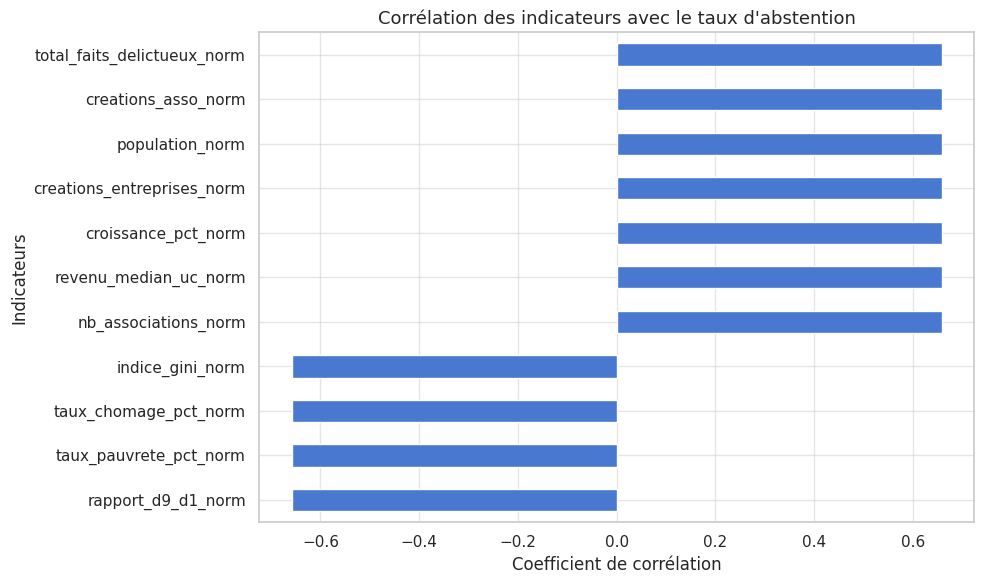

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
correlations_abstention.sort_values().plot(kind="barh")

plt.title("Corrélation des indicateurs avec le taux d'abstention")
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Indicateurs")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(CLEAN_DIR, 'correlation_abstention_rate.png'), dpi=120, bbox_inches='tight')
plt.show()

### Interprétation

Cette analyse permet d'identifier les indicateurs les plus associés au taux d'abstention observé dans les données disponibles.  
Les coefficients proches de 1 indiquent une corrélation positive forte avec l'abstention, tandis que les coefficients proches de -1 indiquent une corrélation négative forte.

Compte tenu du faible nombre d'observations électorales disponibles, ces corrélations doivent être interprétées avec prudence. Elles permettent d'orienter l'analyse exploratoire, mais ne suffisent pas à établir une relation causale.

## Modélisation prédictive supervisée

Le modèle supervisé cherche à apprendre une relation entre les indicateurs socio-économiques et le taux d’abstention.

La variable cible est :

- `taux_abstention`

Les variables explicatives sont les indicateurs normalisés :

- population ;
- chômage ;
- créations d’entreprises ;
- revenus ;
- pauvreté ;
- inégalités ;
- associations ;
- sécurité.

Trois modèles sont comparés :

1. une baseline moyenne ;
2. une régression linéaire ;
3. une régression Ridge.

La baseline sert de référence minimale. Le modèle Ridge est retenu comme modèle final car il est plus stable qu’une régression linéaire classique lorsque le nombre d’observations est faible.

In [46]:
# ============================================================
# 15. Modélisation prédictive supervisée
# ============================================================

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

X = df_model[features_model]
y = df_model["taux_abstention"]

models = {
    "Baseline moyenne": DummyRegressor(strategy="mean"),
    "Régression linéaire": LinearRegression(),
    "Ridge": Ridge(alpha=1.0)
}

resultats_modeles = []

for nom, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)

    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    resultats_modeles.append({
        "modele": nom,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "MAE_en_points": round(mae * 100, 2)
    })

df_resultats_modeles = pd.DataFrame(resultats_modeles)
display(df_resultats_modeles)

,modele,MAE,RMSE,R2,MAE_en_points
0,Baseline moyenne,0.03,0.03,0.00,2.65
1,Régression linéaire,0.03,0.03,0.43,2.59
2,Ridge,0.03,0.03,0.41,2.59


## Validation croisée Leave-One-Out

Le cahier des charges demande de vérifier la fiabilité du modèle à partir d’un jeu d’entraînement et d’un jeu de test.

Comme le dataset électoral ne contient que quatre observations, un découpage classique entraînement/test serait trop instable. Le notebook utilise donc une validation croisée Leave-One-Out.

Le principe est simple :

- une observation est mise de côté pour le test ;
- le modèle est entraîné sur les autres observations ;
- l’opération est répétée jusqu’à ce que chaque observation ait été utilisée une fois comme test.

Cette méthode permet d’évaluer le modèle sur des données non vues, tout en conservant un maximum de données pour l’apprentissage.

In [47]:
# ============================================================
# 15 bis. Validation croisée Leave-One-Out
# ============================================================

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
import numpy as np
import pandas as pd

loo = LeaveOneOut()

models_cv = {
    "Baseline moyenne": DummyRegressor(strategy="mean"),
    "Régression linéaire": LinearRegression(),
    "Ridge": Ridge(alpha=1.0)
}

resultats_cv = []

for nom, model in models_cv.items():
    y_pred_cv = cross_val_predict(model, X, y, cv=loo)

    mae = mean_absolute_error(y, y_pred_cv)
    rmse = np.sqrt(mean_squared_error(y, y_pred_cv))
    r2 = r2_score(y, y_pred_cv)

    resultats_cv.append({
        "modele": nom,
        "MAE_CV": round(mae, 4),
        "RMSE_CV": round(rmse, 4),
        "R2_CV": round(r2, 4),
        "MAE_CV_en_points": round(mae * 100, 2)
    })

df_resultats_cv = pd.DataFrame(resultats_cv)
display(df_resultats_cv)

,modele,MAE_CV,RMSE_CV,R2_CV,MAE_CV_en_points
0,Baseline moyenne,0.04,0.05,-0.78,3.54
1,Régression linéaire,0.05,0.05,-1.27,5.18
2,Ridge,0.05,0.05,-0.92,4.69


### Validation du modèle

Le faible nombre d’observations électorales ne permet pas de réaliser un découpage classique entraînement/test sans perdre trop d’information.  
Une validation croisée Leave-One-Out a donc été utilisée : chaque observation est testée une fois pendant que le modèle est entraîné sur les autres observations.

Cette approche permet de respecter le principe d’évaluation sur des données non vues, tout en restant adaptée au faible volume de données disponible dans le cadre du POC.

## Choix du modèle final

Le modèle Ridge est retenu comme modèle final du POC.

Il s’agit d’une régression linéaire régularisée. Elle limite l’impact de coefficients trop extrêmes, ce qui est utile lorsque le nombre d’observations est faible.

Le modèle final est ensuite entraîné sur l’ensemble des observations disponibles afin de produire les prédictions et les projections futures.

In [48]:
# ============================================================
# 16. Modèle retenu : Ridge
# ============================================================

model_final = Ridge(alpha=1.0)
model_final.fit(X, y)

y_pred = model_final.predict(X)

df_predictions_train = df_model[
    [
        "annee",
        "tour",
        "niveau_geo_electoral",
        "taux_abstention",
        "taux_participation"
    ]
].copy()

df_predictions_train["prediction_taux_abstention"] = y_pred
df_predictions_train["prediction_taux_participation"] = 1 - y_pred

df_predictions_train["erreur_absolue_abstention"] = (
    df_predictions_train["taux_abstention"]
    - df_predictions_train["prediction_taux_abstention"]
).abs()

display(df_predictions_train)

,annee,tour,niveau_geo_electoral,taux_abstention,taux_participation,prediction_taux_abstention,prediction_taux_participation,erreur_absolue_abstention
0,2017,T1,cantons_nantes,0.19,0.81,0.23,0.77,0.03
1,2017,T2,cantons_nantes,0.25,0.75,0.23,0.77,0.03
2,2022,T1,bureaux_vote_nantes,0.24,0.76,0.26,0.74,0.02
3,2022,T2,bureaux_vote_nantes,0.29,0.71,0.26,0.74,0.03


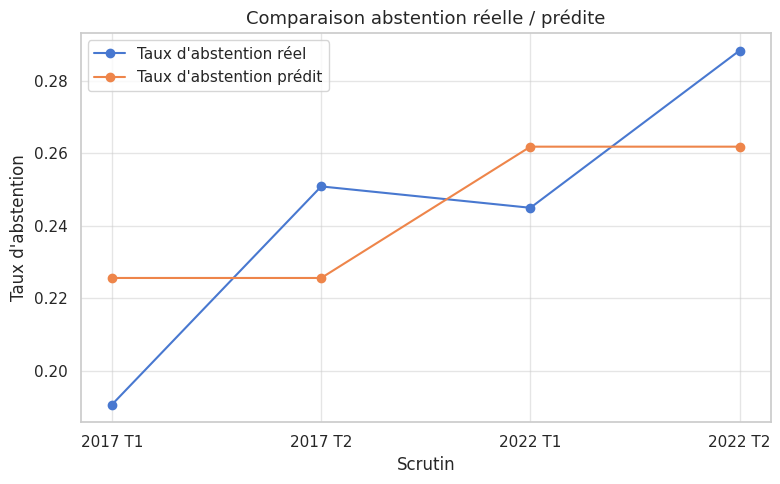

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_predictions_train["annee"].astype(str) + " " + df_predictions_train["tour"],
    df_predictions_train["taux_abstention"],
    marker="o",
    label="Taux d'abstention réel"
)

plt.plot(
    df_predictions_train["annee"].astype(str) + " " + df_predictions_train["tour"],
    df_predictions_train["prediction_taux_abstention"],
    marker="o",
    label="Taux d'abstention prédit"
)

plt.title("Comparaison abstention réelle / prédite")
plt.xlabel("Scrutin")
plt.ylabel("Taux d'abstention")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CLEAN_DIR, 'actual_predicted_abstention.png'), dpi=120, bbox_inches='tight')
plt.show()

## Interprétation du modèle

L’analyse des coefficients permet de comprendre le rôle des variables dans le modèle Ridge.

Un coefficient positif signifie que la variable contribue à augmenter la prédiction du taux d’abstention.

Un coefficient négatif signifie que la variable contribue à diminuer la prédiction du taux d’abstention.

Cette lecture doit rester prudente, car le modèle repose sur un faible nombre d’observations.

In [50]:
# ============================================================
# 17. Analyse des coefficients du modèle Ridge
# ============================================================

df_coefficients = pd.DataFrame({
    "variable": features_model,
    "coefficient": model_final.coef_
})

df_coefficients["coefficient_abs"] = df_coefficients["coefficient"].abs()

df_coefficients = df_coefficients.sort_values(
    "coefficient_abs",
    ascending=False
)

display(df_coefficients)

,variable,coefficient,coefficient_abs
9,taux_pauvrete_pct_norm,-0.01,0.01
6,rapport_d9_d1_norm,-0.01,0.01
3,indice_gini_norm,-0.01,0.01
8,taux_chomage_pct_norm,-0.01,0.01
7,revenu_median_uc_norm,0.01,0.01
5,population_norm,0.01,0.01
1,creations_entreprises_norm,0.00,0.00
0,creations_asso_norm,0.00,0.00
4,nb_associations_norm,0.00,0.00
2,croissance_pct_norm,0.00,0.00


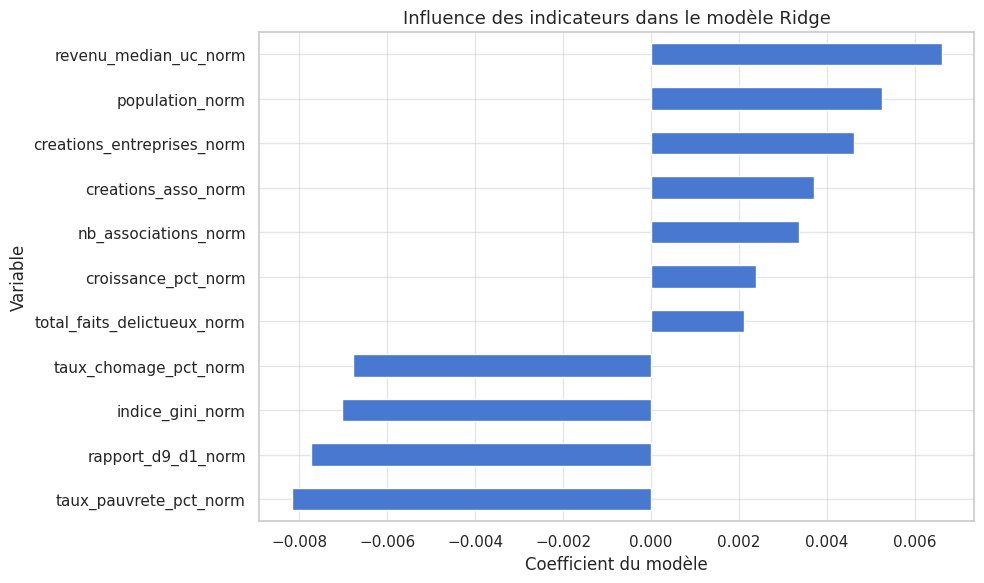

In [58]:
# Graphique des coefficients du modèle Ridge
ax = df_coefficients.sort_values("coefficient").plot(
    x="variable",
    y="coefficient",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)

ax.set_title("Influence des indicateurs dans le modèle Ridge")
ax.set_xlabel("Coefficient du modèle")
ax.set_ylabel("Variable")
ax.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CLEAN_DIR, 'influence_ridge_model.png'), dpi=120, bbox_inches='tight')
plt.show()

### Interprétation des coefficients

Les coefficients du modèle Ridge permettent d’identifier les variables qui influencent le plus la prédiction du taux d’abstention dans le cadre du POC.

Les coefficients positifs contribuent à augmenter la prédiction du taux d’abstention, tandis que les coefficients négatifs contribuent à la diminuer.

Ces coefficients doivent cependant être interprétés avec prudence, car le modèle repose sur un faible nombre d’observations électorales.

## Projection à 1, 2 et 3 ans

Les projections sont réalisées pour les années 2026, 2027 et 2028.

Comme les indicateurs futurs ne sont pas encore connus, ils sont estimés à partir d’une tendance linéaire simple sur les années disponibles.

Les valeurs projetées sont ensuite injectées dans le modèle Ridge afin d’obtenir une estimation du taux d’abstention futur.

Ces projections sont des scénarios exploratoires. Elles ne doivent pas être interprétées comme des prévisions électorales définitives.

In [52]:
# ============================================================
# 18. Projection du taux d'abstention à 1, 2 et 3 ans
# ============================================================

from sklearn.linear_model import LinearRegression

future_years = [2026, 2027, 2028]

df_future = pd.DataFrame({"annee": future_years})

for feature in features_model:
    # Modèle simple de tendance temporelle sur chaque indicateur normalisé
    temp = df_norm[["annee", feature]].dropna().copy()

    model_trend = LinearRegression()
    model_trend.fit(temp[["annee"]], temp[feature])

    pred_feature = model_trend.predict(df_future[["annee"]])

    # On borne entre 0 et 1 car les variables sont normalisées
    df_future[feature] = np.clip(pred_feature, 0, 1)

X_future = df_future[features_model]

future_pred = model_final.predict(X_future)

df_predictions_future = pd.DataFrame({
    "annee": future_years,
    "prediction_taux_abstention": future_pred,
    "prediction_taux_participation": 1 - future_pred
})

display(df_predictions_future)

,annee,prediction_taux_abstention,prediction_taux_participation
0,2026,0.27,0.73
1,2027,0.27,0.73
2,2028,0.27,0.73


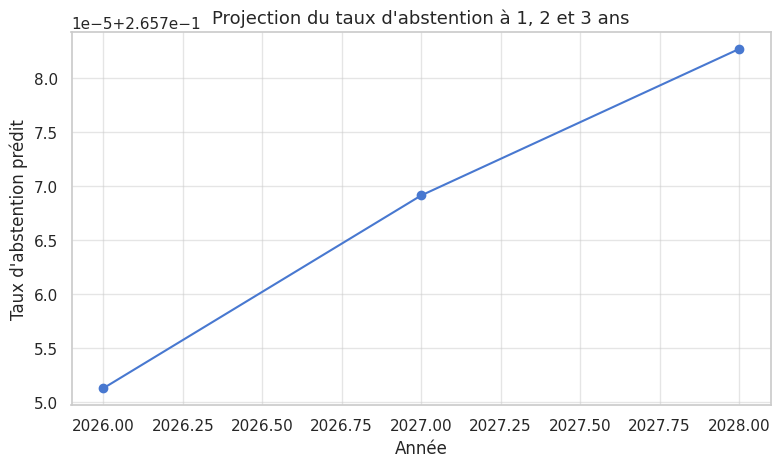

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_predictions_future["annee"],
    df_predictions_future["prediction_taux_abstention"],
    marker="o"
)

plt.title("Projection du taux d'abstention à 1, 2 et 3 ans")
plt.xlabel("Année")
plt.ylabel("Taux d'abstention prédit")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(CLEAN_DIR, 'projection_abstention_rate.png'), dpi=120, bbox_inches='tight')
plt.show()

In [54]:
# ============================================================
# 19. Export des résultats de modélisation
# ============================================================

exports_modelisation = {
    "model_resultats_comparaison.csv": df_resultats_modeles,
    "model_resultats_validation_croisee.csv": df_resultats_cv,
    "model_predictions_train.csv": df_predictions_train,
    "model_coefficients_ridge.csv": df_coefficients,
    "model_predictions_future.csv": df_predictions_future,
}

for fichier, df in exports_modelisation.items():
    chemin = os.path.join(CLEAN_DIR, fichier)
    df.to_csv(chemin, index=False, encoding="utf-8-sig", sep=";")
    print(f"✓ Export modèle : {chemin}")

✓ Export modèle : data/clean/model_resultats_comparaison.csv
✓ Export modèle : data/clean/model_resultats_validation_croisee.csv
✓ Export modèle : data/clean/model_predictions_train.csv
✓ Export modèle : data/clean/model_coefficients_ridge.csv
✓ Export modèle : data/clean/model_predictions_future.csv


In [55]:
# ============================================================
# 20. Récapitulatif final du POC
# ============================================================

print("\n" + "=" * 70)
print("  RÉCAPITULATIF FINAL — POC Electio-Analytics — Nantes")
print("=" * 70)
print(f"  Périmètre géographique : {NOM_COMMUNE} ({CODE_COMMUNE})")
print(f"  Période des indicateurs : {df_clean['annee'].min()} – {df_clean['annee'].max()}")
print(f"  Observations électorales : {len(target_elections)}")
print(f"  Variables explicatives utilisées : {len(features_model)}")
print()
print("  Données électorales utilisées :")
display(target_elections)

print("  Modèles comparés :")
display(df_resultats_modeles)

print("  Validation croisée Leave-One-Out :")
display(df_resultats_cv)

print("  Prédictions futures :")
display(df_predictions_future)

print("=" * 70)


  RÉCAPITULATIF FINAL — POC Electio-Analytics — Nantes
  Périmètre géographique : Nantes (44109)
  Période des indicateurs : 2012 – 2025
  Observations électorales : 4
  Variables explicatives utilisées : 11

  Données électorales utilisées :


,annee,tour,zone_analyse,niveau_geo_electoral,inscrits,votants,blancs,nuls,exprimes,taux_participation,taux_abstention
0,2017,T1,Nantes,cantons_nantes,187820,152010,1942,606,149462,0.81,0.19
1,2017,T2,Nantes,cantons_nantes,187771,140650,11178,2749,126723,0.75,0.25
2,2022,T1,Nantes,bureaux_vote_nantes,196999,148737,1796,547,146394,0.76,0.24
3,2022,T2,Nantes,bureaux_vote_nantes,196895,140108,9571,2379,128158,0.71,0.29


  Modèles comparés :


,modele,MAE,RMSE,R2,MAE_en_points
0,Baseline moyenne,0.03,0.03,0.00,2.65
1,Régression linéaire,0.03,0.03,0.43,2.59
2,Ridge,0.03,0.03,0.41,2.59


  Validation croisée Leave-One-Out :


,modele,MAE_CV,RMSE_CV,R2_CV,MAE_CV_en_points
0,Baseline moyenne,0.04,0.05,-0.78,3.54
1,Régression linéaire,0.05,0.05,-1.27,5.18
2,Ridge,0.05,0.05,-0.92,4.69


  Prédictions futures :


,annee,prediction_taux_abstention,prediction_taux_participation
0,2026,0.27,0.73
1,2027,0.27,0.73
2,2028,0.27,0.73


## Limites et pistes d’amélioration

Le POC démontre la faisabilité d’une chaîne complète de traitement et de prédiction : collecte, nettoyage, normalisation, stockage, analyse exploratoire, modélisation et projection.

La principale limite concerne le faible nombre d’observations électorales disponibles. Le modèle repose sur quatre observations : 2017 T1, 2017 T2, 2022 T1 et 2022 T2. Les résultats doivent donc être interprétés avec prudence.

Pour améliorer la robustesse du modèle, il serait nécessaire d’ajouter davantage d’élections historiques sur le même périmètre géographique : présidentielles 2012, législatives, européennes, municipales ou régionales.

Il serait également pertinent d’ajouter de nouveaux indicateurs : niveau de diplôme, structure par âge, densité de population, logement, mobilité, dépenses publiques locales ou données d’opinion.

En l’état, le projet répond à l’objectif d’un POC : valider la faisabilité technique et méthodologique d’un dispositif de prévision électorale à partir de données publiques.